In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
import os
from sklearn.metrics import auc

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import warnings
from warnings import filterwarnings
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from scipy import stats
from sklearn.preprocessing import PowerTransformer, StandardScaler, RobustScaler, LabelEncoder, PolynomialFeatures
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
%pip install category_encoders
from category_encoders import TargetEncoder, LeaveOneOutEncoder
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
from sklearn.ensemble import RandomForestClassifier
filterwarnings('ignore')
from sklearn.feature_selection import RFECV
import xgboost as xgb
%pip install imbalanced-learn 
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
columns = [
    'hvfhs_license_num',
    'dispatching_base_num',
    'originating_base_num',
    'on_scene_datetime',
    'request_datetime',
    'dropoff_datetime',
    'pickup_datetime',
    'PULocationID',
    'base_passenger_fare',
    'driver_pay',
    'DOLocationID',
    'trip_miles',
    'congestion_surcharge',
    'airport_fee',
    'shared_request_flag',
    'shared_match_flag',
    'access_a_ride_flag', 
    'wav_match_flag',
    'wav_request_flag',
]

In [3]:
'''
Purpose: Speeds up and breaks the dataset into chunks to effectively process information quicker
Parameters: URL Link or File Link to the File to extract
Returns: Dataframe
'''

def extract_file(file_link, chunksize=10000, format_type='parquet'):
    chunks = []
    if format_type == 'parquet':
        df = pd.read_parquet(file_link, columns = columns)
    elif format_type == 'csv':
        for chunk in pd.read_csv(file_link, chunksize=chunksize,header=0):
            chunks.append(chunk)
        df = pd.concat(chunks, ignore_index = True)
    else:
        return 
    return df


In [4]:
# jan2024 = pd.read_parquet('/content/drive/MyDrive/Applications/CISC351/Group Assignment 2/Question 3/fhvhv_tripdata_2024-01.parquet', columns=columns ).sample(frac=0.2, random_state = 42)
feb2024 = extract_file('/Applications/CISC351/Group Assignment/Question 3/Data/fhvhv_tripdata_2024-02.parquet',  format_type='parquet')

#Taxi Zone Lookup CSV
zone_lookup = extract_file('/Applications/CISC351/Group Assignment/Question 3/Data/taxi_zone_lookup.csv', format_type='csv')

In [5]:
#Merged DF with Zone_Lookup to get Corresponding Borough Value
zone_lookup.rename(columns={'LocationID': 'PULocationID'}, inplace=True)
combined_df= feb2024.merge(zone_lookup, on = 'PULocationID', how = 'left', validate='m:1')
combined_df.head(3)

,hvfhs_license_num,dispatching_base_num,originating_base_num,on_scene_datetime,request_datetime,dropoff_datetime,pickup_datetime,PULocationID,base_passenger_fare,driver_pay,DOLocationID,trip_miles,congestion_surcharge,airport_fee,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_match_flag,wav_request_flag,Borough,Zone,service_zone
0,HV0003,B03404,B03404,2024-02-01 00:19:59,2024-02-01 00:13:55,2024-02-01 00:27:54,2024-02-01 00:20:54,149,8.88,5.57,210,1.23,0.0,0.0,N,N,N,N,N,Brooklyn,Madison,Boro Zone
1,HV0003,B03404,B03404,2024-02-01 00:03:28,2024-02-01 00:00:14,2024-02-01 00:09:37,2024-02-01 00:04:37,127,7.91,5.39,136,1.28,0.0,0.0,N,N,N,N,N,Manhattan,Inwood,Boro Zone
2,HV0003,B03404,B03404,2024-02-01 00:15:44,2024-02-01 00:13:57,2024-02-01 00:31:54,2024-02-01 00:17:46,127,17.60,13.13,69,3.93,0.0,0.0,N,N,N,N,N,Manhattan,Inwood,Boro Zone


In [6]:
#Sine and Cosine Encoding allows us to represents Seasonality 
def encode_cyclic(df, col, max_val):
    '''
    Sine and Cosine Encoding used to map cyclic data into continuous bound space
    Model able to distinguish between unique points and hand circular patterns
    '''
    df[col + '_sin'] = np.sin(2 * np.pi * df[col]/max_val)
    df[col + "_cos"] = np.cos(2 * np.pi * df[col]/max_val)
    return df

int64      268
float64     10
int32        2
Name: count, dtype: int64


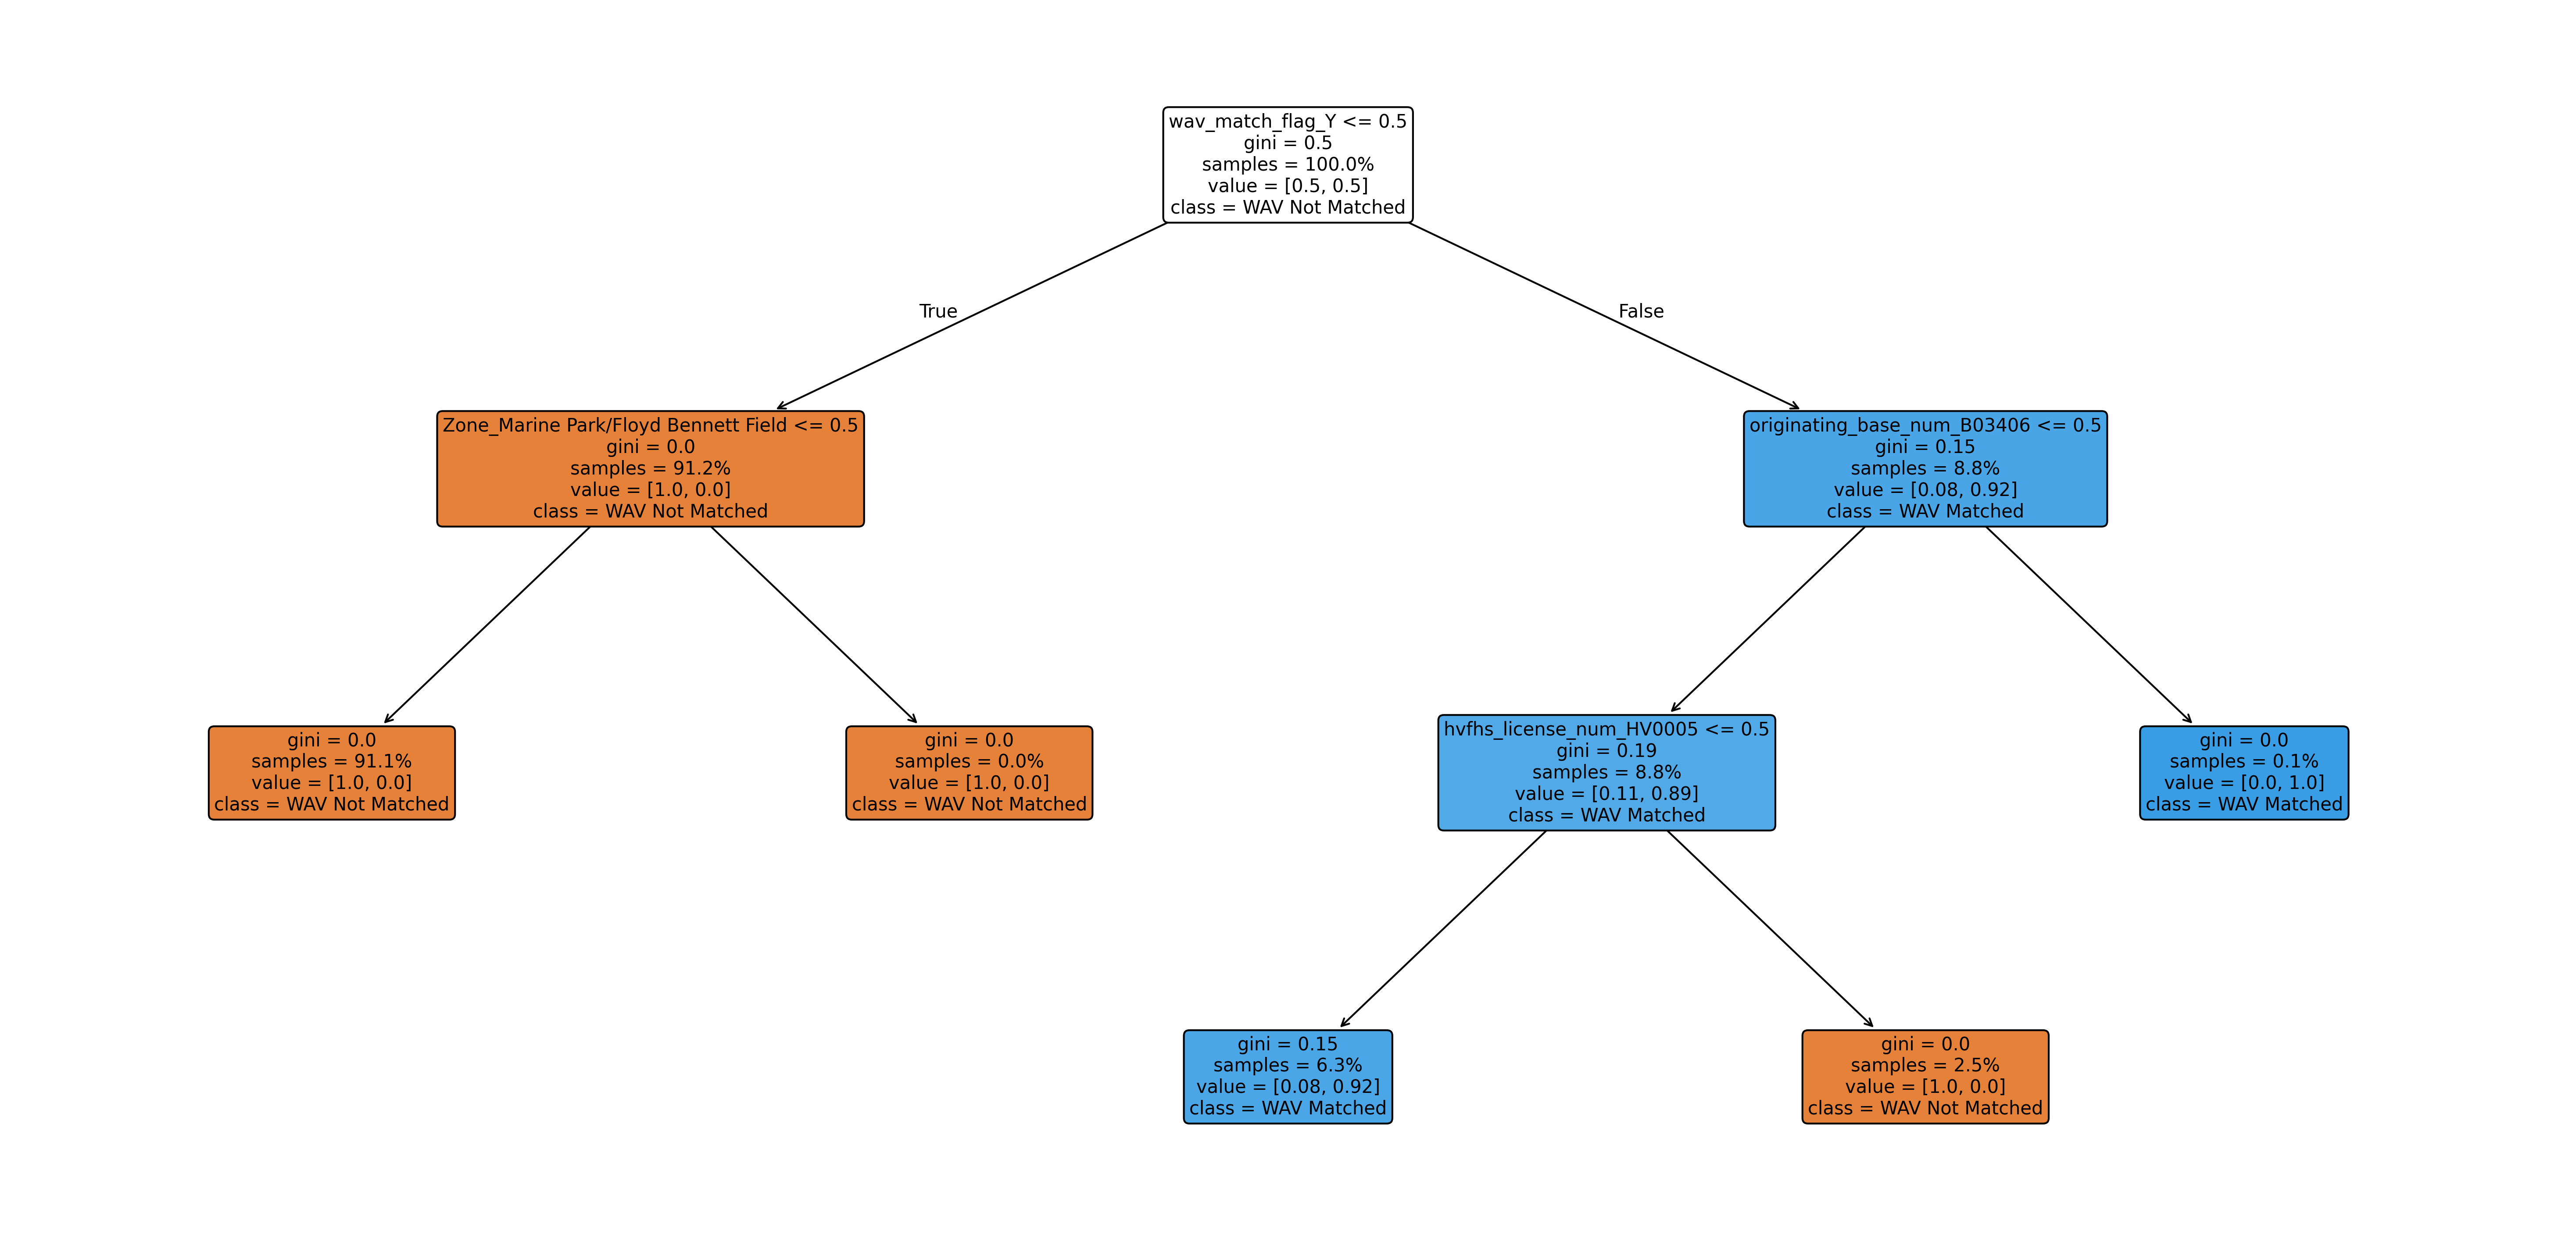

In [13]:
#Decision Tree Classification 3 Depth based on Gini Impurity, Balanced use Inverse of Freq as weight
combined_df_c = combined_df.sample(frac=0.05, random_state = 42).copy()

combined_df_c['hour'] = combined_df_c['request_datetime'].dt.hour
combined_df_c = encode_cyclic(combined_df_c, 'hour', 24)

combined_df_c['day'] = combined_df_c['request_datetime'].dt.dayofweek
combined_df_c = encode_cyclic(combined_df_c, 'day', 7)

combined_df_c['is_night'] = np.where( 
    (combined_df_c['request_datetime'].dt.hour <= 6) | (combined_df_c['request_datetime'].dt.hour >= 21), 
    1, 0)

drop_cols = ['hour', 'day', 'request_datetime', 'pickup_datetime',  'dropoff_datetime', 'on_scene_datetime', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag']
combined_df_c.drop(columns=drop_cols, inplace=True)



X_val = pd.get_dummies(combined_df_c.drop(columns='wav_request_flag'), 
    drop_first=True, dtype=int)

target = combined_df_c['wav_request_flag']

X_train, X_test, y_train, y_test = train_test_split(X_val, target, test_size=0.25, random_state=42)
print(X_train.dtypes.value_counts())
clf = DecisionTreeClassifier(max_depth=3, min_samples_split = 2, 
        class_weight = 'balanced', criterion='gini', 
        random_state =42)
clf.fit(X_train, y_train)


plt.figure(figsize=(25, 12), dpi=300)
plot_tree(clf,
feature_names=X_train.columns,
          class_names=['WAV Not Matched', 'WAV Matched'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True, precision=2)

plt.show()


Insight: 
1) The Decision Tree splits based off WAV_MATCH_FLAG which is similar to our second split

2) The second split is based on HVFHS_License_num where it splits based off company which is our first pslit. 

3) The other splits are too precise and we can not rationalize the decision behind it as it splits off geographical location. We will also use Geographical location but our rational is to consider Socioeconomical factors so we will split based off Richer Broughs vs Poorer Boroughs

In [6]:
def segmentation(df):
    
    Uber = df[ (df["hvfhs_license_num"] == 'HV0003') & (df['shared_request_flag'] == 'N') &
               (df['access_a_ride_flag'] == 'N')  & (df['shared_match_flag'] == 'N')]
    
    Lyft = df[ (df["hvfhs_license_num"] == 'HV0005') & (df['shared_request_flag'] == 'N') &
               (df['access_a_ride_flag'] == 'N')  & (df['shared_match_flag'] == 'N')]

    Uber_WAV = Uber[(Uber['wav_request_flag'] == 'Y')]
    Lyft_WAV = Lyft[(Lyft['wav_request_flag'] == 'Y')]

    return Uber_WAV, Lyft_WAV
    


In [7]:
#Segmentation Block
Uber_WAV, Lyft_WAV = segmentation(combined_df)
all_dfs = [Uber_WAV, Lyft_WAV]


### **Data Exploration(EDA):**

In [8]:
#Create Binary Indicators of certain features 
def binary_event(dfs):
    '''
    Create Binary Event Flags to represent Congestion, Airport, Rich Boroughs
    '''
    for index in range(len(dfs)):
        dfs[index]['congestion_ride'] = dfs[index]['congestion_surcharge'].isnull().astype(int)
        dfs[index]['airport_ride'] = dfs[index]['airport_fee'].isnull().astype(int)
        dfs[index]['is_Rich_Borough'] = dfs[index]['Borough'].isin(['Manhattan', 'Queens', 'Brooklyn'])

    for index in range(len(dfs)):
        dfs[index].drop(columns=['Zone', 'service_zone'], inplace=True)
        
binary_event(all_dfs)

In [9]:
def PULocationConversion(all_dfs):
    #Create a Lookup table to extract Numerical ID and map to Zone Name
    LocationID_map = dict(zip(zone_lookup['PULocationID'], zone_lookup['Zone']))

    for index in range(len(all_dfs)):
        all_dfs[index]['PULocationID'] = all_dfs[index]['PULocationID'].map(LocationID_map)
        all_dfs[index]['DOLocationID'] = all_dfs[index]['DOLocationID'].map(LocationID_map)
        all_dfs[index]['Pair_Destination'] = list(zip(all_dfs[index]['PULocationID'], all_dfs[index]['DOLocationID']))

PULocationConversion(all_dfs)
    



In [10]:
def create_time_cost_vars(all_dfs):
    '''
    All Time Variables other than Hour and Day are measured in total minutes
    '''

    for index in range(len(all_dfs)):
        all_dfs[index]['base_passenger_fare'] = np.where(all_dfs[index]['base_passenger_fare'] < 0, -all_dfs[index]['base_passenger_fare'], all_dfs[index]['base_passenger_fare'])
        all_dfs[index]['wait_time'] = round((all_dfs[index]['on_scene_datetime'] - all_dfs[index]['request_datetime']).dt.total_seconds()/60, 3)

    
create_time_cost_vars(all_dfs)

In [11]:
def additional_feature_created(all_dfs):
    for index in range(len(all_dfs)):
        all_dfs[index]['Borough'] = all_dfs[index]['Borough'].fillna('Outside NYC')
        all_dfs[index]['wait_time'] = np.where(all_dfs[index]['wait_time'] < 0, -all_dfs[index]['wait_time'], all_dfs[index]['wait_time'])
        all_dfs[index]['driver_pay'] = np.where(all_dfs[index]['driver_pay'] < 0, -all_dfs[index]['driver_pay'], all_dfs[index]['driver_pay'])
        all_dfs[index]['wav_request_flag'] = all_dfs[index]['wav_request_flag'].replace({'Y': 1, 'N': 0})
        all_dfs[index]['wav_match_flag'] = all_dfs[index]['wav_match_flag'].replace({'Y': 1, 'N': 0})
        
        #Outlier value, Excluded based off domain knowledge
        all_dfs[index] = all_dfs[index][~all_dfs[index]['Borough'].isin(['EWR'])]
        all_dfs[index] = all_dfs[index][all_dfs[index]['wait_time'] > 0]
        

        # #Dropped Features
        if 'dispatching_base_num' in all_dfs[index].columns:
            all_dfs[index].drop(columns=['dispatching_base_num', 'dropoff_datetime', 'pickup_datetime', 'access_a_ride_flag',
                                            'shared_request_flag', 'shared_match_flag',  'on_scene_datetime', 'originating_base_num'], inplace=True)

        


additional_feature_created(all_dfs)

In [12]:
#Code block: Used to copy dataframe to prevent having to reiterate from start
copy_dfs = []
for index in range(len(all_dfs)):
    copy_dfs.append(all_dfs[index].copy())

#UBER WAV
master_df = copy_dfs[0][~copy_dfs[0]['Borough'].isin(['Outside NYC'])]


In [13]:
#SIN and COS Hour and DAY Values to represent a cycle
master_df = master_df.sort_values('request_datetime').reset_index(drop=True)
master_df['hour_sin'] = np.sin(2 * np.pi * master_df['request_datetime'].dt.hour/24)
master_df['hour_cos'] = np.cos(2 * np.pi * master_df['request_datetime'].dt.hour/24)
master_df['day_sin'] = np.sin(2 * np.pi * master_df['request_datetime'].dt.weekday/7)
master_df['day_cos'] = np.cos(2 * np.pi * master_df['request_datetime'].dt.weekday/7)
master_df['is_rush_hour'] = np.where( 
    (master_df['request_datetime'].dt.dayofweek.isin([0,1,2,3,4]) & (master_df['request_datetime'].dt.hour >= 10) & (master_df['request_datetime'].dt.hour <= 14)) |
    (master_df['request_datetime'].dt.dayofweek.isin([5,6]) & (master_df['request_datetime'].dt.hour >= 15) & (master_df['request_datetime'].dt.hour <= 21)), 
    1, 0)


In [15]:
#Converting wait time into binary target flaf is_High to
master_df['is_High'] = np.where(master_df['wait_time'] > 7 , 1, 0).astype(int)

# A. Geospatial Density (Last Hour)
master_df['pu_density_last_hour'] = (
    master_df.set_index('request_datetime')
    .groupby('PULocationID')['PULocationID']
    .rolling('1h', closed='left').count()
    .reset_index(level=0, drop=True).values
)

master_df['do_density_last_hour'] = (
    master_df.set_index('request_datetime')
    .groupby('DOLocationID')['DOLocationID']
    .rolling('1h', closed='left').count()
    .reset_index(level=0, drop=True).values
)

#WAV Demand Ratio (Last Hour)
wav_req_count = (
    master_df.set_index('request_datetime')
    .groupby('PULocationID')['wav_request_flag']
    .rolling('1h', closed='left').sum()
    .reset_index(level=0, drop=True).values
)
master_df['wav_request_ratio_last_hour'] = (wav_req_count / master_df['pu_density_last_hour']).replace([np.inf, -np.inf], 0)

#Lag Features
master_df['prev_10_trip_wait'] = (
    master_df.groupby('Borough')['wait_time']
    .rolling(window=10, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
    .shift(1)
)

master_df['prev_5_trips_wait_avg'] = (
    master_df.groupby('Borough')['wait_time']
    .rolling(window=5, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
    .shift(1)
)

#TEMPORAL SPLIT dataset
train_size = int(len(master_df) * 0.8)
train_df = master_df.iloc[:train_size].copy()
test_df = master_df.iloc[train_size:].copy()

X_train2 = train_df.drop(columns=['is_High'])
y_train2 = train_df['is_High']
X_test2 = test_df.drop(columns=['is_High'])
y_test2 = test_df['is_High']

#IMPUTATION (USING TRAINING STATISTICS ONLY)
pu_mean = X_train2['pu_density_last_hour'].mean()
do_mean = X_train2['do_density_last_hour'].mean()
ratio_mean = X_train2['wav_request_ratio_last_hour'].mean()
wait_10_mean = X_train2['prev_10_trip_wait'].mean()
wait_5_mean = X_train2['prev_5_trips_wait_avg'].mean()

for df in [X_train2, X_test2]:
    df['pu_density_last_hour'] = df['pu_density_last_hour'].fillna(pu_mean)
    df['do_density_last_hour'] = df['do_density_last_hour'].fillna(do_mean)
    df['wav_request_ratio_last_hour'] = df['wav_request_ratio_last_hour'].fillna(ratio_mean)
    df['prev_10_trip_wait'] = df['prev_10_trip_wait'].fillna(wait_10_mean)
    df['prev_5_trips_wait_avg'] = df['prev_5_trips_wait_avg'].fillna(wait_5_mean)

#DERIVED FEATURES (AFTER IMPUTATION)
X_train2['net_vehicle_flow'] = X_train2['pu_density_last_hour'] - X_train2['do_density_last_hour']
X_test2['net_vehicle_flow'] = X_test2['pu_density_last_hour'] - X_test2['do_density_last_hour']
X_train2 = X_train2.drop(columns=['wait_time'])
X_test2 = X_test2.drop(columns='wait_time')

In [ ]:
def new_box_plot_creation(df):
    numerical_cols = df.select_dtypes(include=['number']).columns
    for col in numerical_cols:
        plt.figure(figsize=(10,8))
        sns.boxplot(data = df, x = 'hvfhs_license_num', y = col, hue = 'hvfhs_license_num')
        plt.xticks(rotation=45)
        plt.title(f'Box plot for {col} Comparing Different Ride Types')
        plt.ylabel('Value')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
            
        
new_box_plot_creation(X_train2)
    

In [17]:
#BoxPlot Transformation
def boxplot_transform(df, feature, transform=None, final_confirmation = False):
     if transform == None:
        return 
     if final_confirmation == False:
        copy = df.copy()
        if transform == 'log':
            copy[f'{feature}_log'] = np.log(copy[feature] + 1)
            plt.figure(figsize=(10,8))
         
        if transform == 'sqrt':
            copy[f'{feature}_sqrt'] = np.sqrt(copy[feature])
            plt.figure(figsize=(10,8))

        if transform == 'cbrt':
            copy[f'{feature}_cbrt'] = np.cbrt(copy[feature])
            plt.figure(figsize=(10,8))

        if transform == 'yj':
            pt = PowerTransformer(method='yeo-johnson', standardize=True)
            copy[f'{feature}_yj'] = pt.fit_transform(copy[[f'{feature}']])

        if transform == 'inverse':
            copy[f'{feature}_inverse'] = 1/(copy[f"{feature}"]+ 0.01)

        if transform == 'winsorize':
            #Anything in top 1% is considered an outlier and should be cut from the data
            upper_limit = copy[feature].quantile(0.99) 
            lower_limit = copy[feature].quantile(0.01)
            copy[f"{feature}_winsorize"] = copy[feature].clip(lower=lower_limit, upper=upper_limit)

        if transform == 'robust_scaler':
            scaler = RobustScaler()
            copy[feature] = scaler.fit_transform(copy[[feature]])


        if transform not in ['robust_scaler', 'scaler']:
            skewness = copy[f'{feature}_{transform}'].skew()
            print('Skewness:', skewness)

            fig, axes = plt.subplots(nrows=1, ncols = 2, figsize=(10,8))
            axes[0].tick_params(axis='x', rotation = 45)
            axes[0].set_title(f"Box Plot for {feature}_{transform}")
            axes[0].set_ylabel('Value')
            sns.boxplot(data=copy, y =f'{feature}_{transform}', ax=axes[0])


            axes[1].tick_params(axis='x', rotation = 45)
            axes[1].set_title(f"Hist Plot for {feature}_{transform}")
            axes[1].set_ylabel('Value')
            sns.histplot(data = copy, x =f'{feature}_{transform}', kde = True, ax = axes[1])
            plt.show()
        else:
            skewness = copy[feature].skew()
            print('Skewness', skewness)

            fig, axes = plt.subplots(nrows=1, ncols = 2, figsize=(10,8))
            axes[0].tick_params(axis='x', rotation = 45)
            axes[0].set_title(f"Box Plot for Scaled {feature}")
            axes[0].set_ylabel('Value')
            sns.boxplot(data=copy, y = f'{feature}', ax=axes[0])


            axes[1].tick_params(axis='x', rotation = 45)
            axes[1].set_title(f"Hist Plot for Scaled {feature}")
            axes[1].set_ylabel('Value')
            sns.histplot(data = copy, x =f'{feature}', kde = True, ax = axes[1])
            plt.show()


     elif final_confirmation == True:
        if transform == 'log':
            df[f'{feature}_log'] = np.log1p(df[feature])
            plt.figure(figsize=(10,8))

        if transform == 'sqrt':
            df[f'{feature}_sqrt'] = np.sqrt(df[feature])
            plt.figure(figsize=(10,8))

        if transform == 'cbrt':
            df[f'{feature}_cbrt'] = np.cbrt(df[feature])
            plt.figure(figsize=(10,8))
        
        if transform == 'yj':
            pt = PowerTransformer(method='yeo-johnson', standardize=True)
            df[f'{feature}_yj'] = pt.fit_transform(df[[f'{feature}']])

        if transform == 'winsorize':
            #Anything in top 1% is considered an outlier and should be cut from the data, will cap at 99th percentile
            upper_limit = df[feature].quantile(0.99) 
            lower_limit = df[feature].quantile(0.01)
            df[f"{feature}_winsorize"] = df[feature].clip(lower=lower_limit, upper=upper_limit)
        
        if transform == 'robust_scaler':
            scaler = RobustScaler()
            df[feature] = scaler.fit_transform(df[[feature]])


        if transform not in ['robust_scaler', 'scaler']:
            skewness = df[f'{feature}_{transform}'].skew()
            print('Skewness', skewness)

            fig, axes = plt.subplots(nrows=1, ncols = 2, figsize=(10,8))
            axes[0].tick_params(axis='x', rotation = 45)
            axes[0].set_title(f"Box Plot for {feature}_{transform}")
            axes[0].set_ylabel('Value')
            sns.boxplot(data=df, y = f'{feature}_{transform}', ax=axes[0])
        

            axes[1].tick_params(axis='x', rotation = 45)
            axes[1].set_title(f"Hist Plot for {feature}_{transform}")
            axes[1].set_ylabel('Value')
            sns.histplot(data = df, x =f'{feature}_{transform}', kde = True,  ax = axes[1])
            plt.show()



        else:
            skewness = df[feature].skew()
            print('Skewness', skewness)

            fig, axes = plt.subplots(nrows=1, ncols = 2, figsize=(10,8))
            axes[0].tick_params(axis='x', rotation = 45)
            axes[0].set_title(f"Box Plot for Scaled {feature} for different Ride Types")
            axes[0].set_ylabel('Value')
            sns.boxplot(data=df, y = f'{feature}', ax=axes[0])
        

            axes[1].tick_params(axis='x', rotation = 45)
            axes[1].set_title(f"Hist Plot for Scaled {feature} for different Ride Types")
            axes[1].set_ylabel('Value')
            sns.histplot(data = df, x =f'{feature}', kde = True, ax = axes[1])
            plt.show()

        



In [ ]:
def transform_features(dfs):
    for index in range(len(dfs)):
        boxplot_transform(dfs[index], 'trip_miles', transform = 'log', final_confirmation=True)
        boxplot_transform(dfs[index], 'trip_miles_log', transform = 'winsorize', final_confirmation=True)

        boxplot_transform(dfs[index], 'base_passenger_fare', transform='log', final_confirmation=True)
        boxplot_transform(dfs[index], 'base_passenger_fare_log', transform='winsorize', final_confirmation=True)

        boxplot_transform(dfs[index], 'driver_pay', transform='log', final_confirmation=True)
        boxplot_transform(dfs[index], 'driver_pay_log', transform='winsorize', final_confirmation=True)

        boxplot_transform(dfs[index], 'prev_5_trips_wait_avg', transform='log', final_confirmation=True)
        boxplot_transform(dfs[index], 'prev_5_trips_wait_avg_log', transform='winsorize', final_confirmation=True)

        boxplot_transform(dfs[index], 'prev_10_trip_wait', transform='log', final_confirmation=True)
        boxplot_transform(dfs[index], 'prev_10_trip_wait_log', transform='winsorize', final_confirmation=True)

        boxplot_transform(dfs[index], 'net_vehicle_flow', transform='cbrt', final_confirmation=True)

        dfs[index]['airport_fee'] = dfs[index]['airport_fee'].astype(str)
        dfs[index] = pd.get_dummies(dfs[index], columns=['airport_fee'], prefix='airport', drop_first=True)
        dfs[index] = dfs[index].drop(columns=['trip_miles','base_passenger_fare', 'driver_pay', 
                        'prev_5_trips_wait_avg', 'prev_10_trip_wait', 'net_vehicle_flow'])



transform_features([X_train2, X_test2])

In [19]:
def destination_encode(dfs):
    '''
    Reconvert PU, DO, Pair_Destination back to Numerical Values to prepare for Target Encoding as these three feature have high cardinality
    '''
    remap = dict(zip(zone_lookup['Zone'], zone_lookup['PULocationID']))
    for index in range(len(dfs)):
        dfs[index]['PULocationID'] = dfs[index]['PULocationID'].map(remap).astype(int)
        dfs[index]['DOLocationID'] = dfs[index]['DOLocationID'].map(remap).astype(int)
        dfs[index]['Pair_Destination'] = list(zip(dfs[index]['PULocationID'], dfs[index]['DOLocationID']))

    destination_encode([X_train2, X_test2])

X_train2 = pd.get_dummies(X_train2, columns=['hvfhs_license_num', 'Borough'], drop_first=True)
X_test2 = pd.get_dummies(X_test2, columns=['hvfhs_license_num', 'Borough'], drop_first=True)

#Apply Leave One Out Target Encoding to prevent Multicolinarity and Data Leakage
loo_encoder = LeaveOneOutEncoder(cols=['PULocationID', 'DOLocationID', 'Pair_Destination'])
X_train_encoded = loo_encoder.fit_transform(X_train2, y_train2)
X_test_encoded = loo_encoder.transform(X_test2)

In [20]:
def extract_request_datetime(df):
    '''
    Extracts all Time Variables for Request Time to be used in interactions later on 
    ''' 
    
    for index in range(len(df)):
        df[index]['request_datetime'] = pd.to_datetime(df[index]['request_datetime'], errors='coerce')
        df[index]['request_day'] = df[index]['request_datetime'].dt.dayofweek
        df[index]['request_hour'] = df[index]['request_datetime'].dt.hour
        df[index]['request_month'] = df[index]['request_datetime'].dt.month
        df[index]['request_minute'] = df[index]['request_datetime'].dt.minute
        df[index]['request_seconds'] = df[index]['request_datetime'].dt.second
        df[index] = df[index].drop(columns=['request_datetime'], inplace=True)


extract_request_datetime([X_train_encoded, X_test_encoded])

### Applying Class Imabalance Startegy

In [21]:
print(y_train2.value_counts())
#Its not really a big difference as its a 1/3 ratio so we dont really need SMOTE but apply just in case

is_High
0    18085
1     7567
Name: count, dtype: int64


In [22]:
''' 
TOMEK SMOTE TO improve boundaries as class_weight = 'balanced' failed
Improving the threshold probability also failed moving from 0.5 to 0.3-0.5 range
Feature Seperability, tried to the best of our capability, we have limited info so Feature Engineer could not resolve
'''

smote = SMOTE(k_neighbors = 5, random_state = 42)
tomek = TomekLinks(sampling_strategy='all')
smt = SMOTETomek(smote=smote, tomek = tomek, random_state = 42)

X_train_encoded, y_train2 = smt.fit_resample(X_train_encoded, y_train2)

In [23]:
print(y_train2.value_counts())

is_High
0    17691
1    17691
Name: count, dtype: int64


### Feature Selection based on Correlation Matrix and VIF

<Axes: >

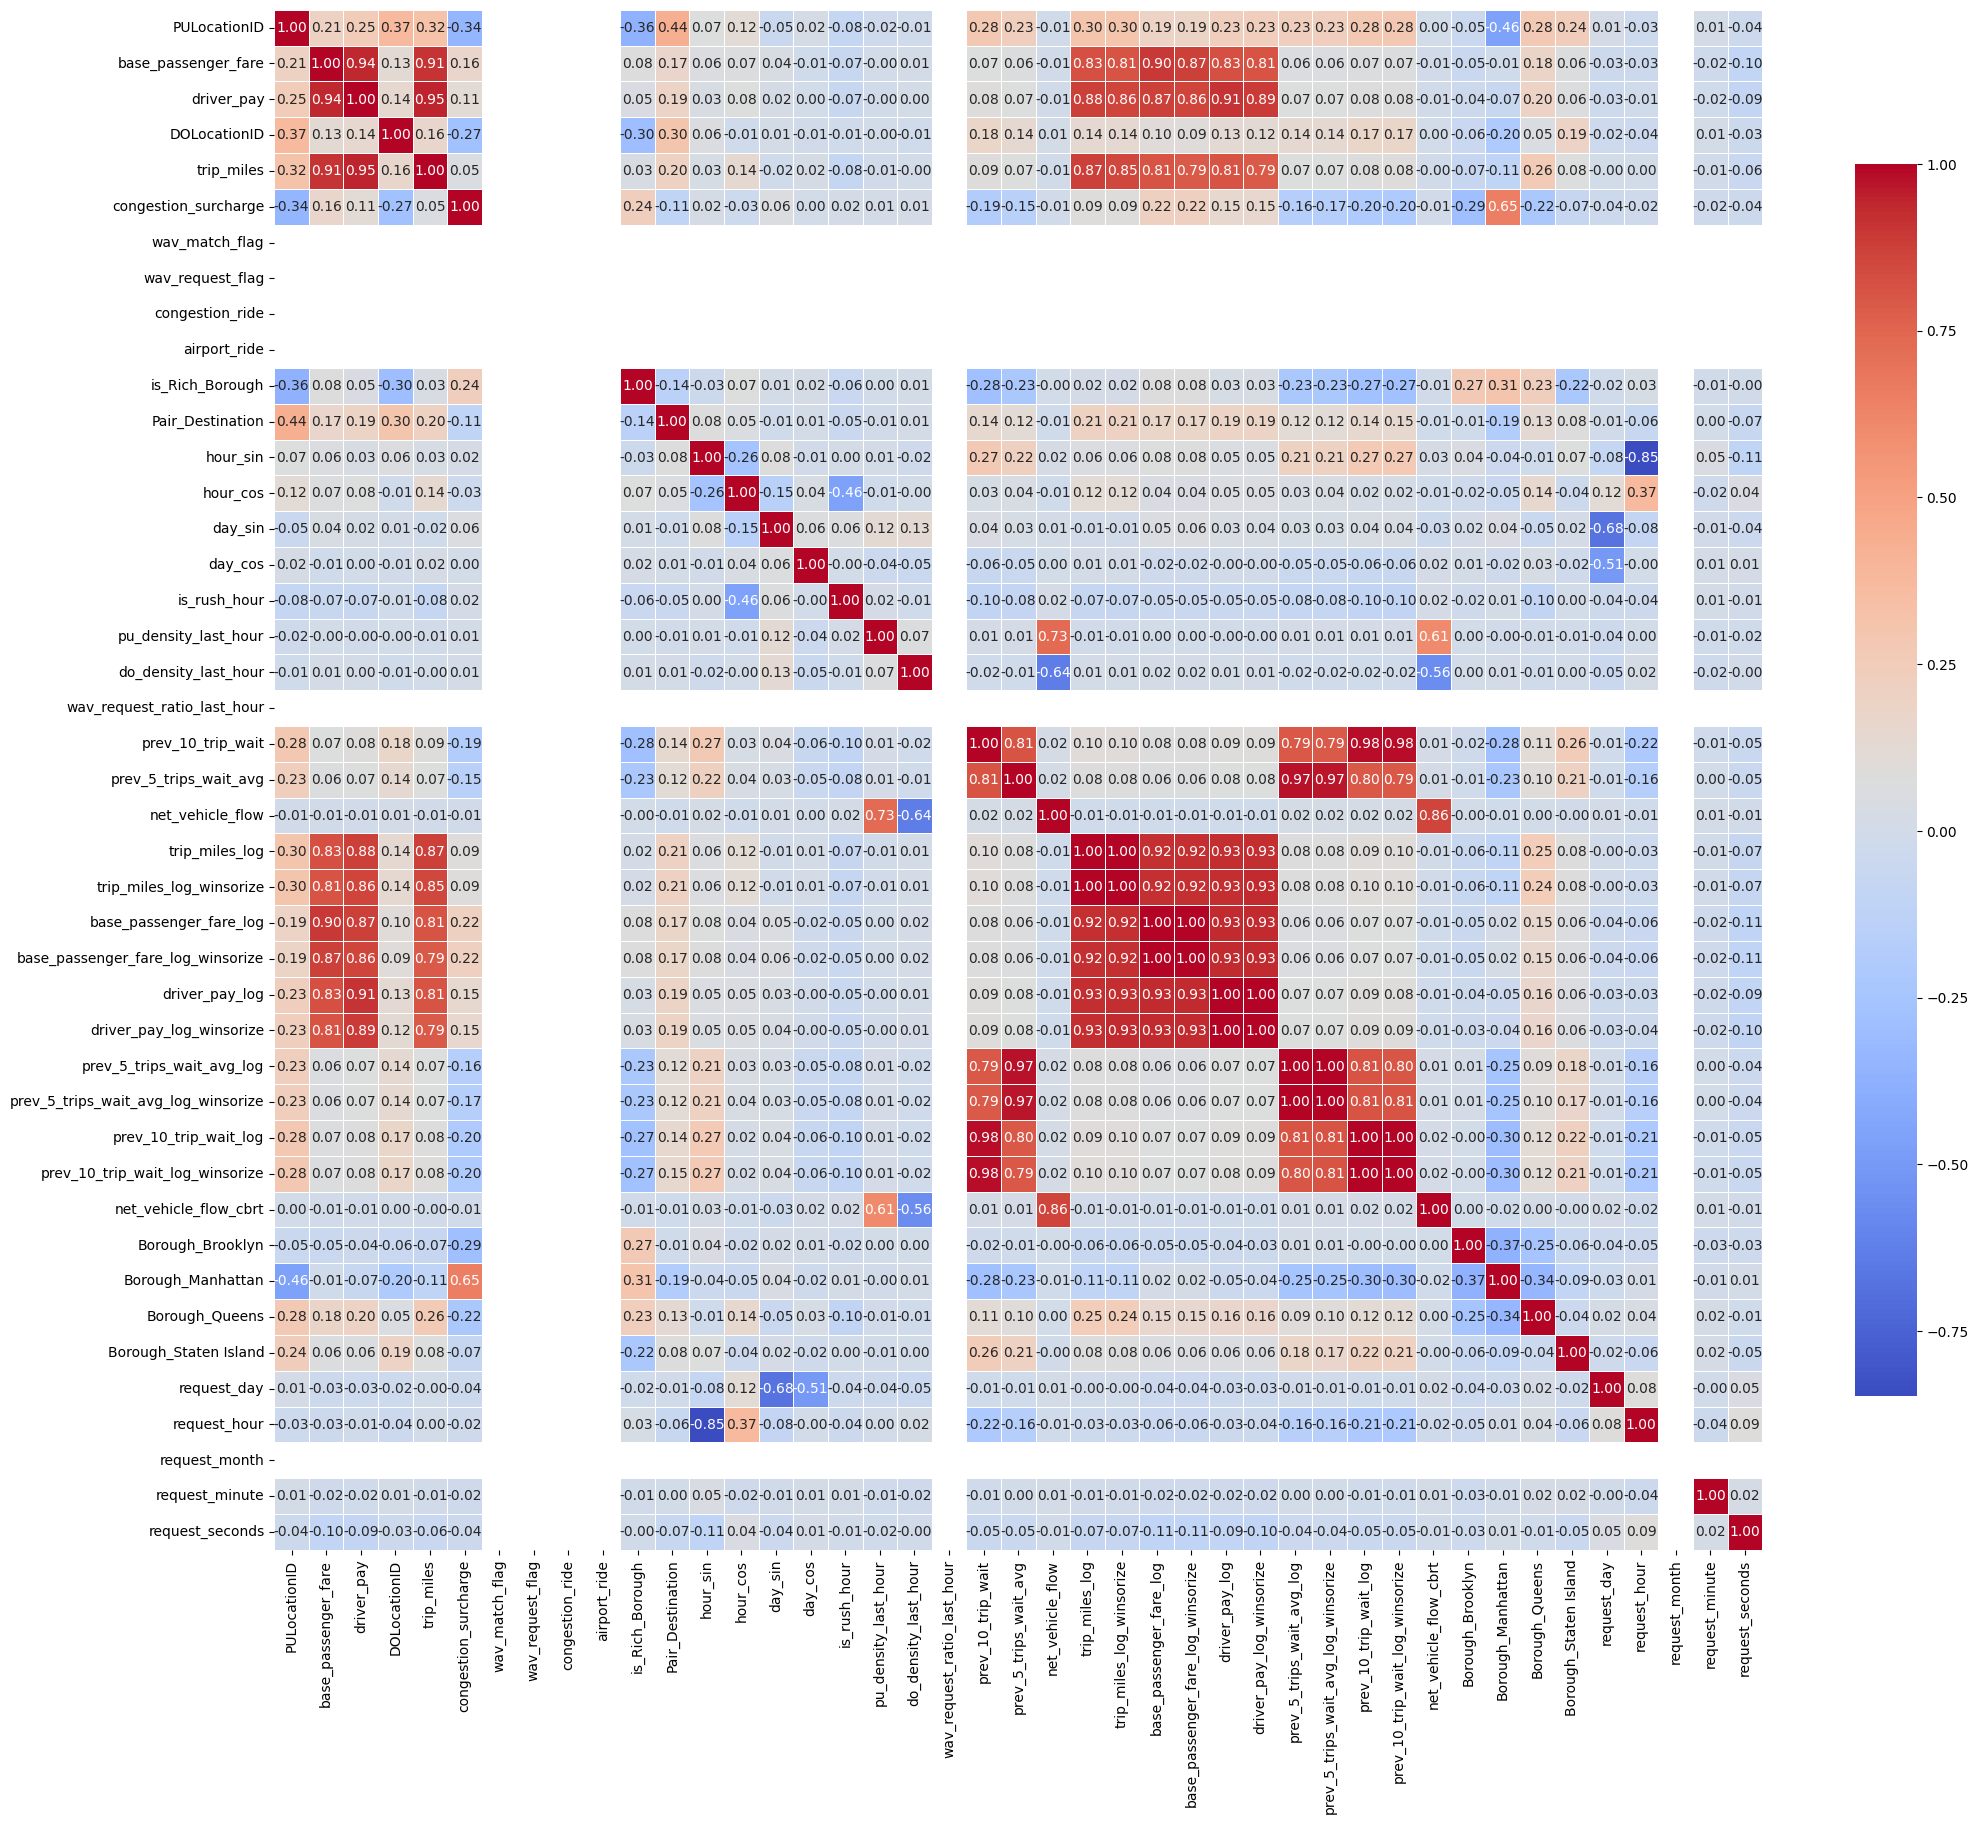

In [27]:
#Correlation MATRIX of Numerical Independent Variable
numerical_cols = X_train_encoded.select_dtypes(include=['bool', 'int', 'float']).columns
correlation_df = X_train_encoded[numerical_cols].corr(method='pearson')
plt.figure(figsize=(24, 20)) 
sns.heatmap(
    correlation_df,         
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    linewidths=0.5,          
    cbar_kws={"shrink": .8}  
)


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encoded_df = pd.concat([X_train_encoded.reset_index(drop=True), 
                        y_train2.reset_index(drop=True)], axis=1)
encoded_df['is_High'] = le.fit_transform(encoded_df['is_High'])
dependent_correlation = encoded_df.corr(method='pearson')[['is_High']].sort_values(by='is_High', ascending=False)
plt.figure(figsize=(20,20))
sns.heatmap(
    dependent_correlation,
    annot = True,
    fmt = '.2f',
    cmap='coolwarm', 
    linewidths=0.5,          
    cbar_kws={"shrink": .8}  
    
)
plt.show()

In [ ]:
le = LabelEncoder()
encoded_df2 = pd.concat([X_train_encoded.reset_index(drop=True), 
                        y_train2.reset_index(drop=True)], axis=1)
encoded_df2['is_High'] = le.fit_transform(encoded_df2['is_High'])
dependent_correlation2 = encoded_df2.corr(method='spearman')[['is_High']].sort_values(by='is_High', ascending=False)
plt.figure(figsize=(20,20))
sns.heatmap(
    dependent_correlation2,
    annot = True,
    fmt = '.2f',
    cmap='coolwarm', 
    linewidths=0.5,          
    cbar_kws={"shrink": .8}  
    
)
plt.show()

In [30]:
#Assumption Checks, ensure Heatmap is similar to VIF [FIX THIS AND FIGURE OUT HOW ---> Issue with Bool values made np.inf as variance was inf]
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = X_train_encoded.apply(pd.to_numeric, errors='coerce')
vif_df = vif_df.astype(float)
vif_df = vif_df.select_dtypes(include=['number'])
intercept = add_constant(vif_df)
vif_data = pd.DataFrame()
vif_data['Feature'] = intercept.columns
vif_data['VIF_Score'] = [variance_inflation_factor(intercept.values, i) for i in range(intercept.shape[1])]
print(vif_data.reset_index().sort_values(by='VIF_Score', ascending=False))

    index                              Feature    VIF_Score
23     23                     net_vehicle_flow          inf
19     19                 do_density_last_hour          inf
18     18                 pu_density_last_hour          inf
24     24                       trip_miles_log  1153.968255
25     25             trip_miles_log_winsorize  1054.912038
26     26              base_passenger_fare_log   625.101495
27     27    base_passenger_fare_log_winsorize   549.046721
32     32                prev_10_trip_wait_log   397.817299
30     30            prev_5_trips_wait_avg_log   384.419477
31     31  prev_5_trips_wait_avg_log_winsorize   314.564573
33     33      prev_10_trip_wait_log_winsorize   310.190391
29     29             driver_pay_log_winsorize   255.312647
28     28                       driver_pay_log   245.017679
21     21                    prev_10_trip_wait    56.829171
2       2                           driver_pay    49.710183
4       4                           trip

Insights: 
1) Between Drive Payer and Trip Miles and Base Passenger Fare either keep 1 or 2, too high multicolinarity. Driver pay strongest correlation with Target Feature so we will keep Diver pay instead
2) Prev_10 and Prev_5 are basically same with Prev_10 accounting for Prev_5 so drop Prev_5
3) Hour Sin and Request_Hour are similar but we wanna know if Cyclic is better than Regular 
4) Net_Vehicle is the sum of PUDensity and DODensity so we may remove Net as PU and DO Density can explain this
5) Majority of our features are weak predictors so we are unsure how get strong features

In [31]:
kept_columns =['PULocationID', 'driver_pay', 'DOLocationID',
       'trip_miles', 'congestion_surcharge', 'airport_fee', 'wav_match_flag',
       'wav_request_flag', 'congestion_ride', 'airport_ride',
       'is_Rich_Borough', 'Pair_Destination', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'is_rush_hour', 'pu_density_last_hour',
       'do_density_last_hour', 'wav_request_ratio_last_hour',
       'prev_10_trip_wait', 'net_vehicle_flow',
       'driver_pay_log_winsorize',
       'prev_5_trips_wait_avg_log_winsorize', 'prev_10_trip_wait_log',
       'prev_10_trip_wait_log_winsorize',
       'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens',
       'Borough_Staten Island', 'request_day', 'request_hour', 'request_month',
       'request_minute', 'request_seconds'
       ]

In [24]:
#INTERACTIONS CREATED
def interactions_created(dfs):
    '''
    Create all Combination Pair Interactions given a certain subset of features, interaction_only = True to create only interactive vars
    '''
    poly = PolynomialFeatures(degree = 2, interaction_only=True, include_bias = True)
    poly_array = poly.fit_transform(dfs[0])
    poly_array2 = poly.transform(dfs[1])
    poly_name = poly.get_feature_names_out(dfs[0].columns)
    poly_name2 = poly.get_feature_names_out(dfs[1].columns)
    return pd.DataFrame(poly_array, columns=poly_name, index=dfs[0].index), pd.DataFrame(poly_array2, columns=poly_name2, index=dfs[1].index)

core_cols = ['driver_pay', 'driver_pay_log_winsorize', 'PULocationID', 'is_rush_hour', 'wav_request_flag', 
'pu_density_last_hour', 'Borough_Manhattan', 'do_density_last_hour', 'prev_10_trip_wait_log_winsorize'
]
train_interactions, test_interactions = interactions_created([X_train_encoded[core_cols], X_test_encoded[core_cols]])
X_train_encoded = pd.concat([X_train_encoded, train_interactions.drop(columns=core_cols)], axis=1)
X_test_encoded = pd.concat([X_test_encoded, test_interactions.drop(columns=core_cols)], axis=1)
    

In [25]:
#Realistic Features
new_kept_features = ['PULocationID', 'driver_pay', 'DOLocationID',
       'trip_miles', 'congestion_surcharge', 'airport_fee', 'wav_match_flag',
       'wav_request_flag', 'congestion_ride', 'airport_ride',
       'is_Rich_Borough', 'Pair_Destination', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'is_rush_hour', 'pu_density_last_hour',
       'do_density_last_hour', 'wav_request_ratio_last_hour',
       'prev_10_trip_wait', 'net_vehicle_flow',
       'driver_pay_log_winsorize',
       'prev_5_trips_wait_avg_log_winsorize', 'prev_10_trip_wait_log',
       'prev_10_trip_wait_log_winsorize',
       'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens',
       'Borough_Staten Island', 'request_day', 'request_hour', 'request_month',
       'request_minute', 'request_seconds', 'PULocationID is_rush_hour', 
       'wav_request_flag pu_density_last_hour', 'wav_request_flag Borough_Manhattan',
       'pu_density_last_hour do_density_last_hour'
       ]

X_train_encoded = X_train_encoded[new_kept_features]
X_test_encoded = X_test_encoded[new_kept_features]

Note: We are not sure whether or not Target Leakage or Target Proxying is occuring. Driver pay could be a Target Proxy but our assumption is that Driver use the payment they get to determine if they wanna pick someone up


### Validation to see how well new interactions are in predicting is_High

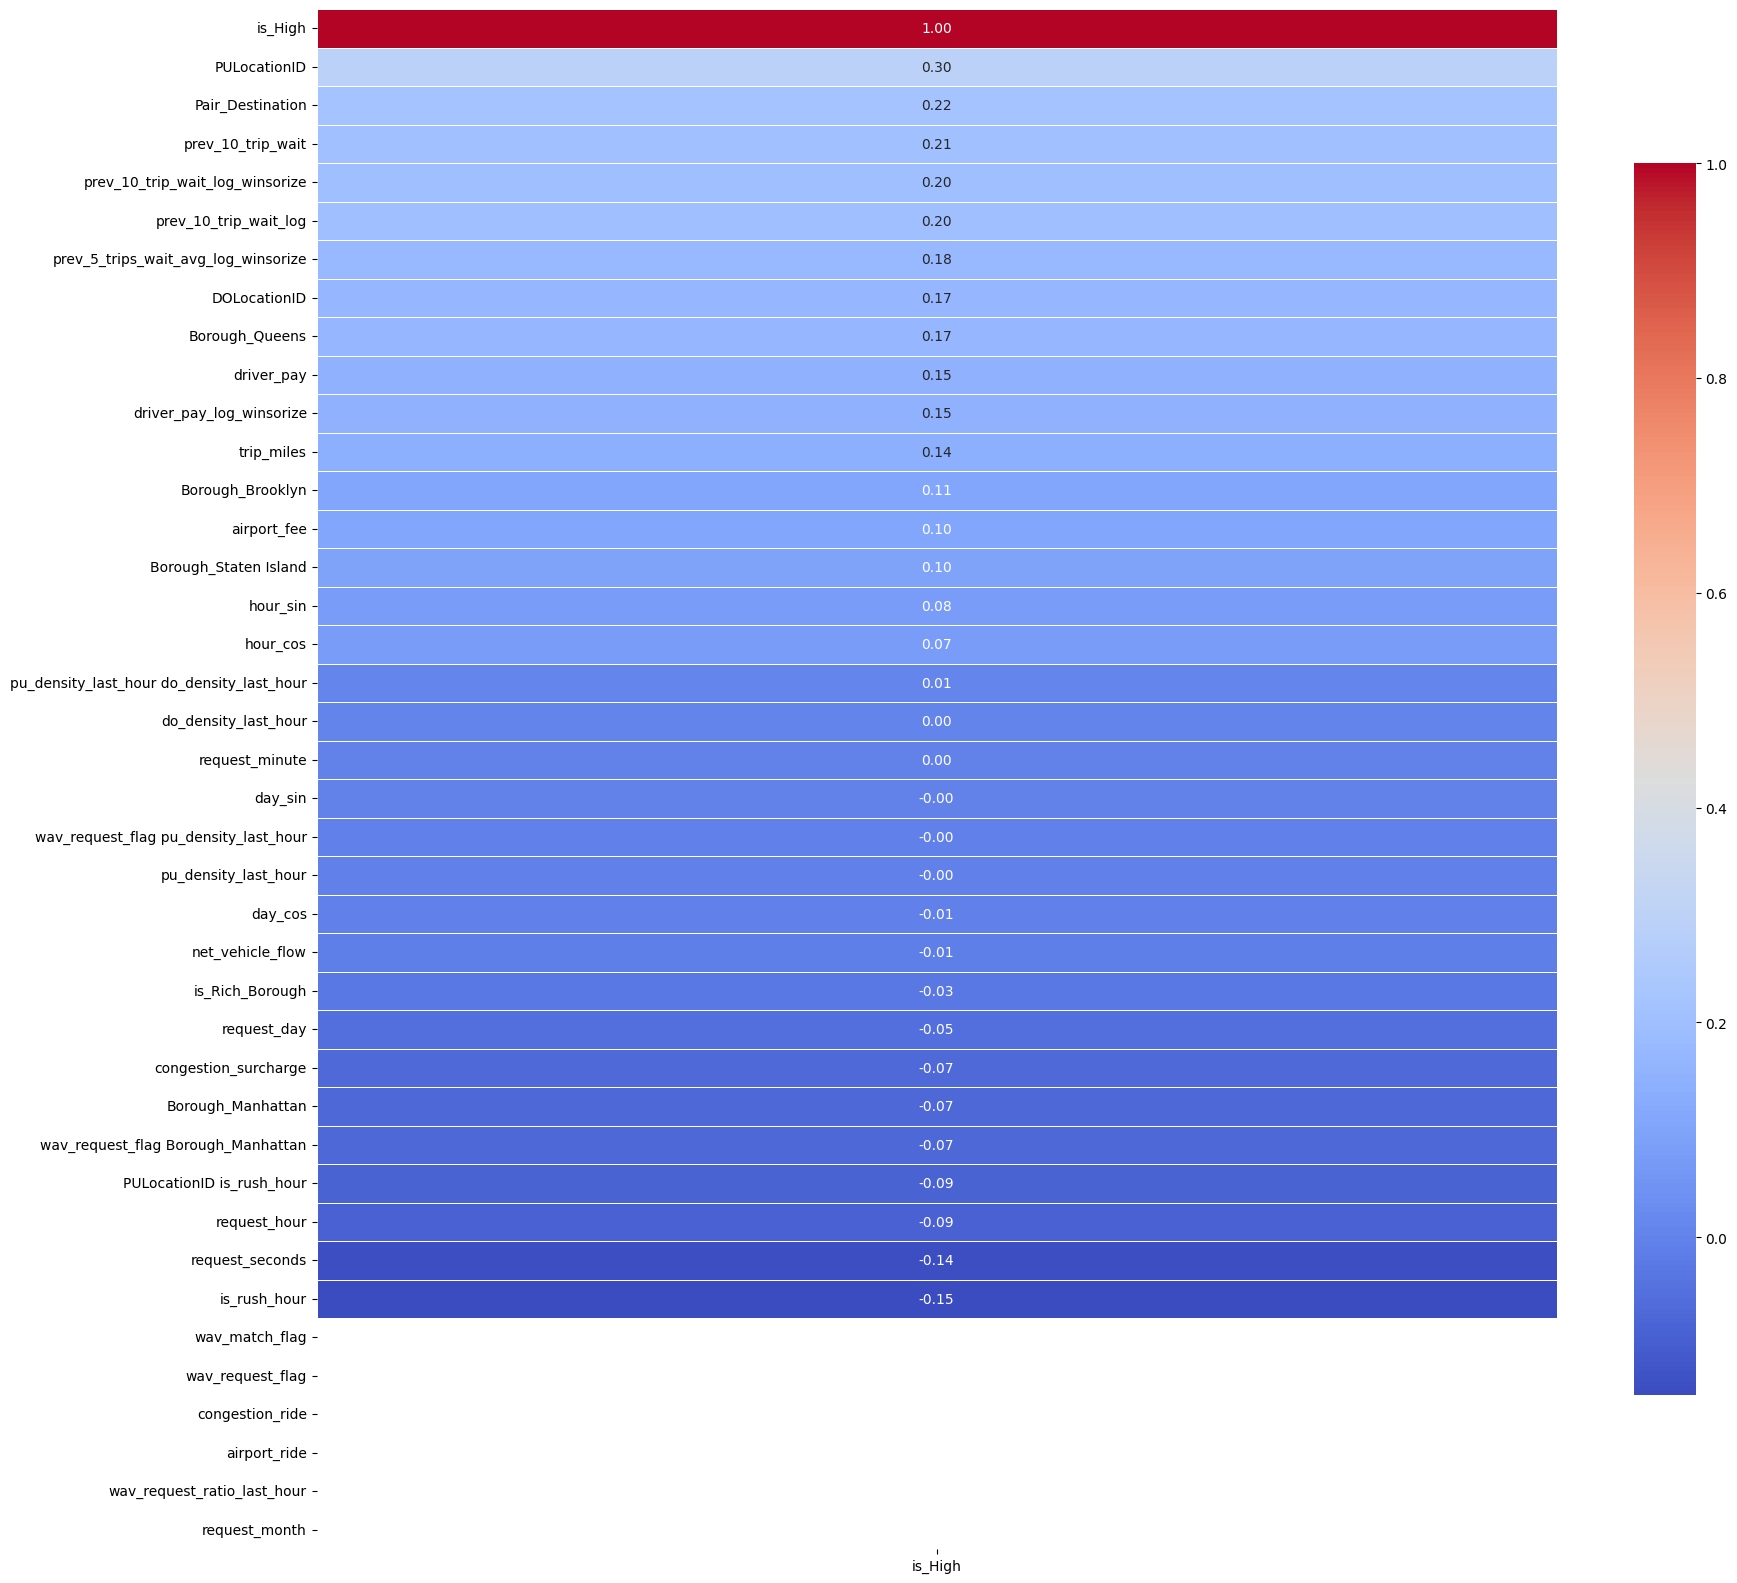

In [36]:
le = LabelEncoder()
encoded_df2 = pd.concat([X_train_encoded.reset_index(drop=True), 
                        y_train2.reset_index(drop=True)], axis=1)
encoded_df2['is_High'] = le.fit_transform(encoded_df2['is_High'])
dependent_correlation2 = encoded_df2.corr(method='spearman')[['is_High']].sort_values(by='is_High', ascending=False)
plt.figure(figsize=(20,20))
sns.heatmap(
    dependent_correlation2,
    annot = True,
    fmt = '.2f',
    cmap='coolwarm', 
    linewidths=0.5,          
    cbar_kws={"shrink": .8}  
    
)
plt.show()

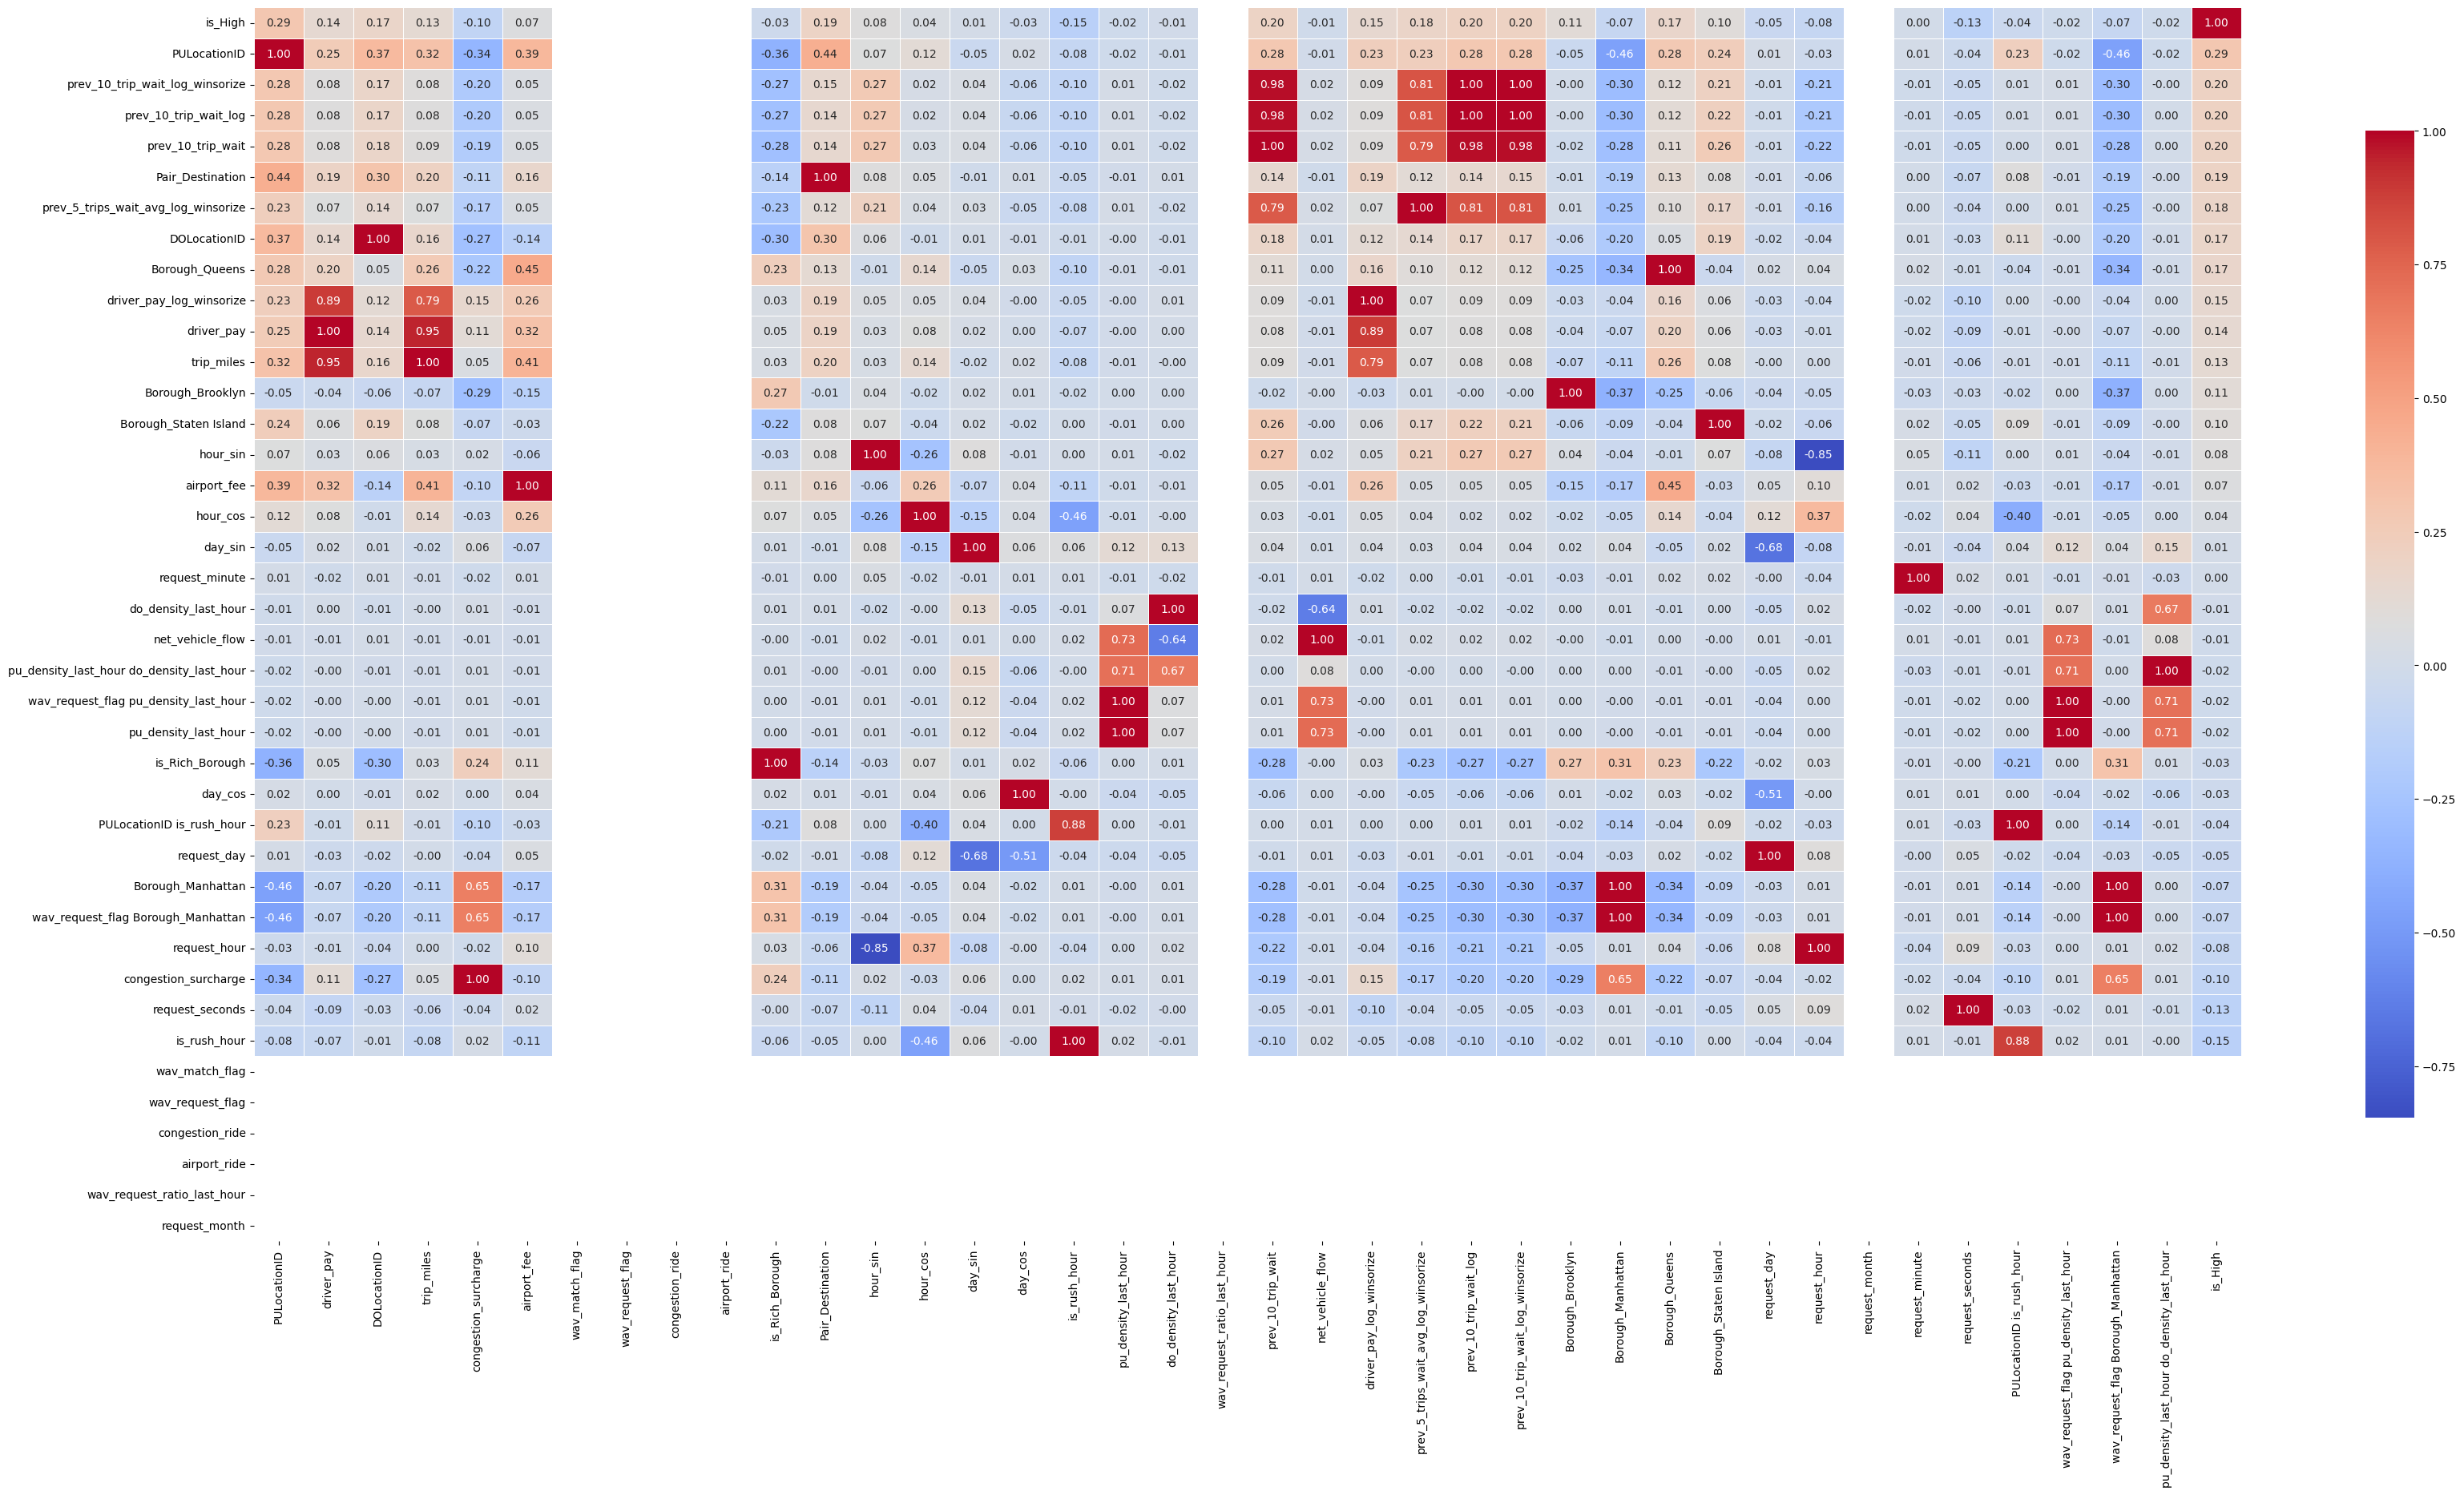

In [37]:
encoded_df2 = pd.concat([X_train_encoded.reset_index(drop=True), 
                        y_train2.reset_index(drop=True)], axis=1)
dependent_correlation2 = encoded_df2.corr(method='pearson').sort_values(by='is_High', ascending=False)
plt.figure(figsize=(40,20))
sns.heatmap(
    dependent_correlation2,
    annot = True,
    fmt = '.2f',
    cmap='coolwarm', 
    linewidths=0.5,          
    cbar_kws={"shrink": .8}  
    
)
plt.show()

Outcome: Interactions did not help improve the model, its better for the XGB Model and RFC model to find the interactions themself, the log model will suffer but adding interactions just create more nusence

In [26]:
kept_columns =['PULocationID', 'driver_pay', 'DOLocationID',
       'trip_miles', 'congestion_surcharge', 'airport_fee', 'wav_match_flag',
       'wav_request_flag', 'congestion_ride', 'airport_ride',
       'is_Rich_Borough', 'Pair_Destination', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'is_rush_hour', 'pu_density_last_hour do_density_last_hour',
       'do_density_last_hour', 'wav_request_ratio_last_hour',
       'prev_10_trip_wait', 'net_vehicle_flow',
       'driver_pay_log_winsorize',
       'prev_10_trip_wait_log_winsorize',
       'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens',
       'Borough_Staten Island', 'request_day', 'request_hour', 'request_month',
       'request_minute', 'request_seconds'
       ]

X_train_encoded = X_train_encoded[kept_columns]
X_test_encoded = X_test_encoded[kept_columns]

### Base Model: Logistic Regression Model

In [27]:
#Scale Features to have on same scale to prevent difference of scales being reason for poor model calibration
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)
X_train_encoded_c = X_train_encoded
X_test_encoded_c = X_test_encoded

In [28]:
def evaluation(true_class, predicted_class):
    print('classification_report')
    print(classification_report(true_class, predicted_class))
    print('Confusion Matrix')
    print(confusion_matrix(true_class, predicted_class))

In [29]:
log_model = LogisticRegression(
    C=0.01, solver='saga', class_weight = 'balanced', random_state=42, penalty='l2', max_iter = 1000, n_jobs =-1
    )


log_model.fit(X_train_scaled, y_train2)
result_df = pd.DataFrame(columns=['f1_score (Random Fold)', 'model', 'Feature Importance'])
y_pred = log_model.predict(X_test_scaled)



#WHY LOC because Initalized as empty so no rows even if you create column it just creates col while others already had rows
result_df.loc[0, 'f1_score (Random Fold)'] = f1_score(y_test2, y_pred, average = 'macro')
result_df.loc[0, 'model'] = 'LogisticRegression'
result_df.head(1)


,f1_score (Random Fold),model,Feature Importance
0,0.622295,LogisticRegression,NaN


### Validation of Model and confirming assumptions

In [30]:
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    index=X_test_encoded_c.index,
    columns=X_test_encoded_c.columns
)

In [31]:
y_probs = log_model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_probs > 0.50).astype(int)
print(f1_score(y_test2, y_pred, average='macro'))
evaluation(y_test2, y_pred)

0.622294867603792
classification_report
              precision    recall  f1-score   support

           0       0.77      0.76      0.77      4459
           1       0.47      0.49      0.48      1954

    accuracy                           0.68      6413
   macro avg       0.62      0.62      0.62      6413
weighted avg       0.68      0.68      0.68      6413

Confusion Matrix
[[3392 1067]
 [1004  950]]


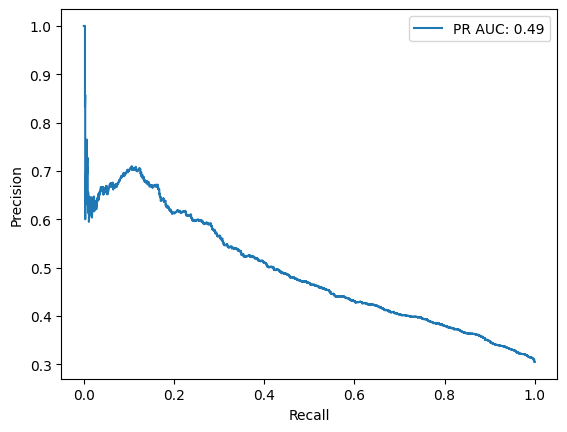

In [46]:
precision, recall, thresholds = precision_recall_curve(y_test2, y_probs)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'PR AUC: {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()        
plt.show()


In [47]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(log_model, X_train_scaled, y_train2, cv=cv, scoring='f1_macro')
scores

array([0.7070777 , 0.71426254, 0.71129734, 0.71103437, 0.69393287,
       0.70067165, 0.70115896, 0.72105121, 0.70588608, 0.70295264])

Results: The Model is overfitting on train data either due to Target Leakage or Target Proxying. We also know for a certain that we were unable find the balance between optimal wait time cut off even with descriptive stats. Results below should be take with precaution as we cannot say with statistical significance these findings hold true. We need more datasets such as one with Temporal or Precepition, the amount features given to the model are insufficent. Another thing we may do is instead focusion on F1, we should maybe focus on Precision or Recall dependening on the situation we are lookng at

### Logistic Regression Model Coefficents, Log Odds to be used for RQ1 Analysis

In [48]:
coef_df = pd.DataFrame({'Feature': X_train_encoded_c.columns, 'Coef': log_model.coef_.flatten()})
coef_df = coef_df.sort_values(by='Coef', ascending=False).reset_index(drop=True)
coef_df  

,Feature,Coef
0,Borough_Manhattan,1.419768
1,Borough_Brooklyn,1.343889
2,Borough_Queens,1.228267
3,PULocationID,0.648145
4,prev_10_trip_wait_log_winsorize,0.357609
5,driver_pay_log_winsorize,0.157820
6,DOLocationID,0.126122
7,Pair_Destination,0.122268
8,Borough_Staten Island,0.070425
9,driver_pay,0.050202


In [49]:
log_odds = log_model.coef_[0]
odds_df = pd.DataFrame({
    'Feature': X_train_encoded_c.columns, 
    'Log_Odds': abs(log_odds),
    'Odds_Ratio': np.exp(log_odds),
    'Sign of Log_Odds': np.where(log_odds > 0 , 'Positive', 'Negative')
})

odds_df = odds_df.sort_values(by='Log_Odds', ascending=False).reset_index(drop=True)
odds_df



,Feature,Log_Odds,Odds_Ratio,Sign of Log_Odds
0,Borough_Manhattan,1.419768,4.136161,Positive
1,Borough_Brooklyn,1.343889,3.833923,Positive
2,Borough_Queens,1.228267,3.415305,Positive
3,is_Rich_Borough,0.724361,0.484634,Negative
4,PULocationID,0.648145,1.911990,Positive
5,prev_10_trip_wait_log_winsorize,0.357609,1.429907,Positive
6,request_day,0.272735,0.761295,Negative
7,is_rush_hour,0.231113,0.793650,Negative
8,request_seconds,0.218698,0.803564,Negative
9,day_cos,0.188756,0.827989,Negative


### Trying a Random Forest Classifier 

- Able to handle Nonlinear relationships and multicolinearity really well

In [36]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced_subsample')
rfc.fit(X_train_scaled, y_train2)
y_pred = rfc.predict(X_test_scaled)

print("\nFeature Importances:")
feature_importances = pd.Series(rfc.feature_importances_, index=X_train_encoded_c.columns).sort_values(ascending=False)
print(feature_importances)
evaluation(y_test2, y_pred)
result_df.loc[1] = {'f1_score (Random Fold)': f1_score(y_test2, y_pred , average='macro') , 'model': 'RFC'}
        



Feature Importances:
PULocationID                                 0.121650
request_seconds                              0.079952
DOLocationID                                 0.066826
Pair_Destination                             0.064036
prev_10_trip_wait                            0.051742
prev_10_trip_wait_log_winsorize              0.046432
trip_miles                                   0.044599
driver_pay_log_winsorize                     0.043722
driver_pay                                   0.043171
pu_density_last_hour do_density_last_hour    0.039814
request_minute                               0.039470
do_density_last_hour                         0.038474
hour_cos                                     0.038000
day_cos                                      0.037643
hour_sin                                     0.033681
congestion_surcharge                         0.033402
day_sin                                      0.032535
net_vehicle_flow                             0.032492
reques

In [ ]:
#CROSS VALIDATION
scores = cross_val_score(rfc, X_train_scaled, y_train2, cv=5, scoring='f1_macro')
scores

Insight: Overfitting on the Train dataset, failing to predict for is_High this is due to fact our features are not significant enough to be able to predict for other classes

### Applying RFE to see what the Model thinks is the most important features needed to improve the model

In [37]:
#Recursive Feature Elimination(Find max features to maximize model performance)
selector = RFECV(estimator=rfc, cv = StratifiedKFold(5), min_features_to_select = 6)
selector = selector.fit(X_train_scaled, y_train2)
print("Selected Features (Mask):", selector.support_)
print("Feature Ranking:", selector.ranking_)
selected_features = X_train_encoded_c.columns[selector.support_]
not_selected = X_train_encoded_c.columns[~selector.support_]


Selected Features (Mask): [ True False  True False False False False False False False False  True
 False  True False False False False False False  True False False False
 False False False False False False False False  True]
Feature Ranking: [ 1  2  1  5  9 19 27 26 25 24 21  1 12  1 11  3 20  4  7 23  1 13  8  6
 17 18 16 22 15 14 28 10  1]


In [38]:
print('Selected Features', selected_features)
print('Not Selected Features', not_selected)

Selected Features Index(['PULocationID', 'DOLocationID', 'Pair_Destination', 'hour_cos',
       'prev_10_trip_wait', 'request_seconds'],
      dtype='object')
Not Selected Features Index(['driver_pay', 'trip_miles', 'congestion_surcharge', 'airport_fee',
       'wav_match_flag', 'wav_request_flag', 'congestion_ride', 'airport_ride',
       'is_Rich_Borough', 'hour_sin', 'day_sin', 'day_cos', 'is_rush_hour',
       'pu_density_last_hour do_density_last_hour', 'do_density_last_hour',
       'wav_request_ratio_last_hour', 'net_vehicle_flow',
       'driver_pay_log_winsorize', 'prev_10_trip_wait_log_winsorize',
       'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens',
       'Borough_Staten Island', 'request_day', 'request_hour', 'request_month',
       'request_minute'],
      dtype='object')


In [39]:
new_rfc = RandomForestClassifier(n_estimators=100, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded_c[selected_features])
X_test_scaled = scaler.transform(X_test_encoded_c[selected_features])
new_rfc.fit(X_train_scaled, y_train2)
y_pred = new_rfc.predict(X_test_scaled)


result_df.loc[2] = {'f1_score (Random Fold)': f1_score(y_test2, y_pred , average='macro'), 'model': 'RFC + RFE'}

print("\nFeature Importances:")
feature_importances = pd.Series(new_rfc.feature_importances_, index=X_train_encoded_c[selected_features].columns).sort_values(ascending=False)
print(feature_importances)
evaluation(y_test2, y_pred)




Feature Importances:
PULocationID         0.269127
DOLocationID         0.170269
hour_cos             0.145792
Pair_Destination     0.140427
request_seconds      0.139426
prev_10_trip_wait    0.134959
dtype: float64
classification_report
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      4459
           1       0.49      0.50      0.49      1954

    accuracy                           0.69      6413
   macro avg       0.63      0.64      0.64      6413
weighted avg       0.69      0.69      0.69      6413

Confusion Matrix
[[3457 1002]
 [ 986  968]]


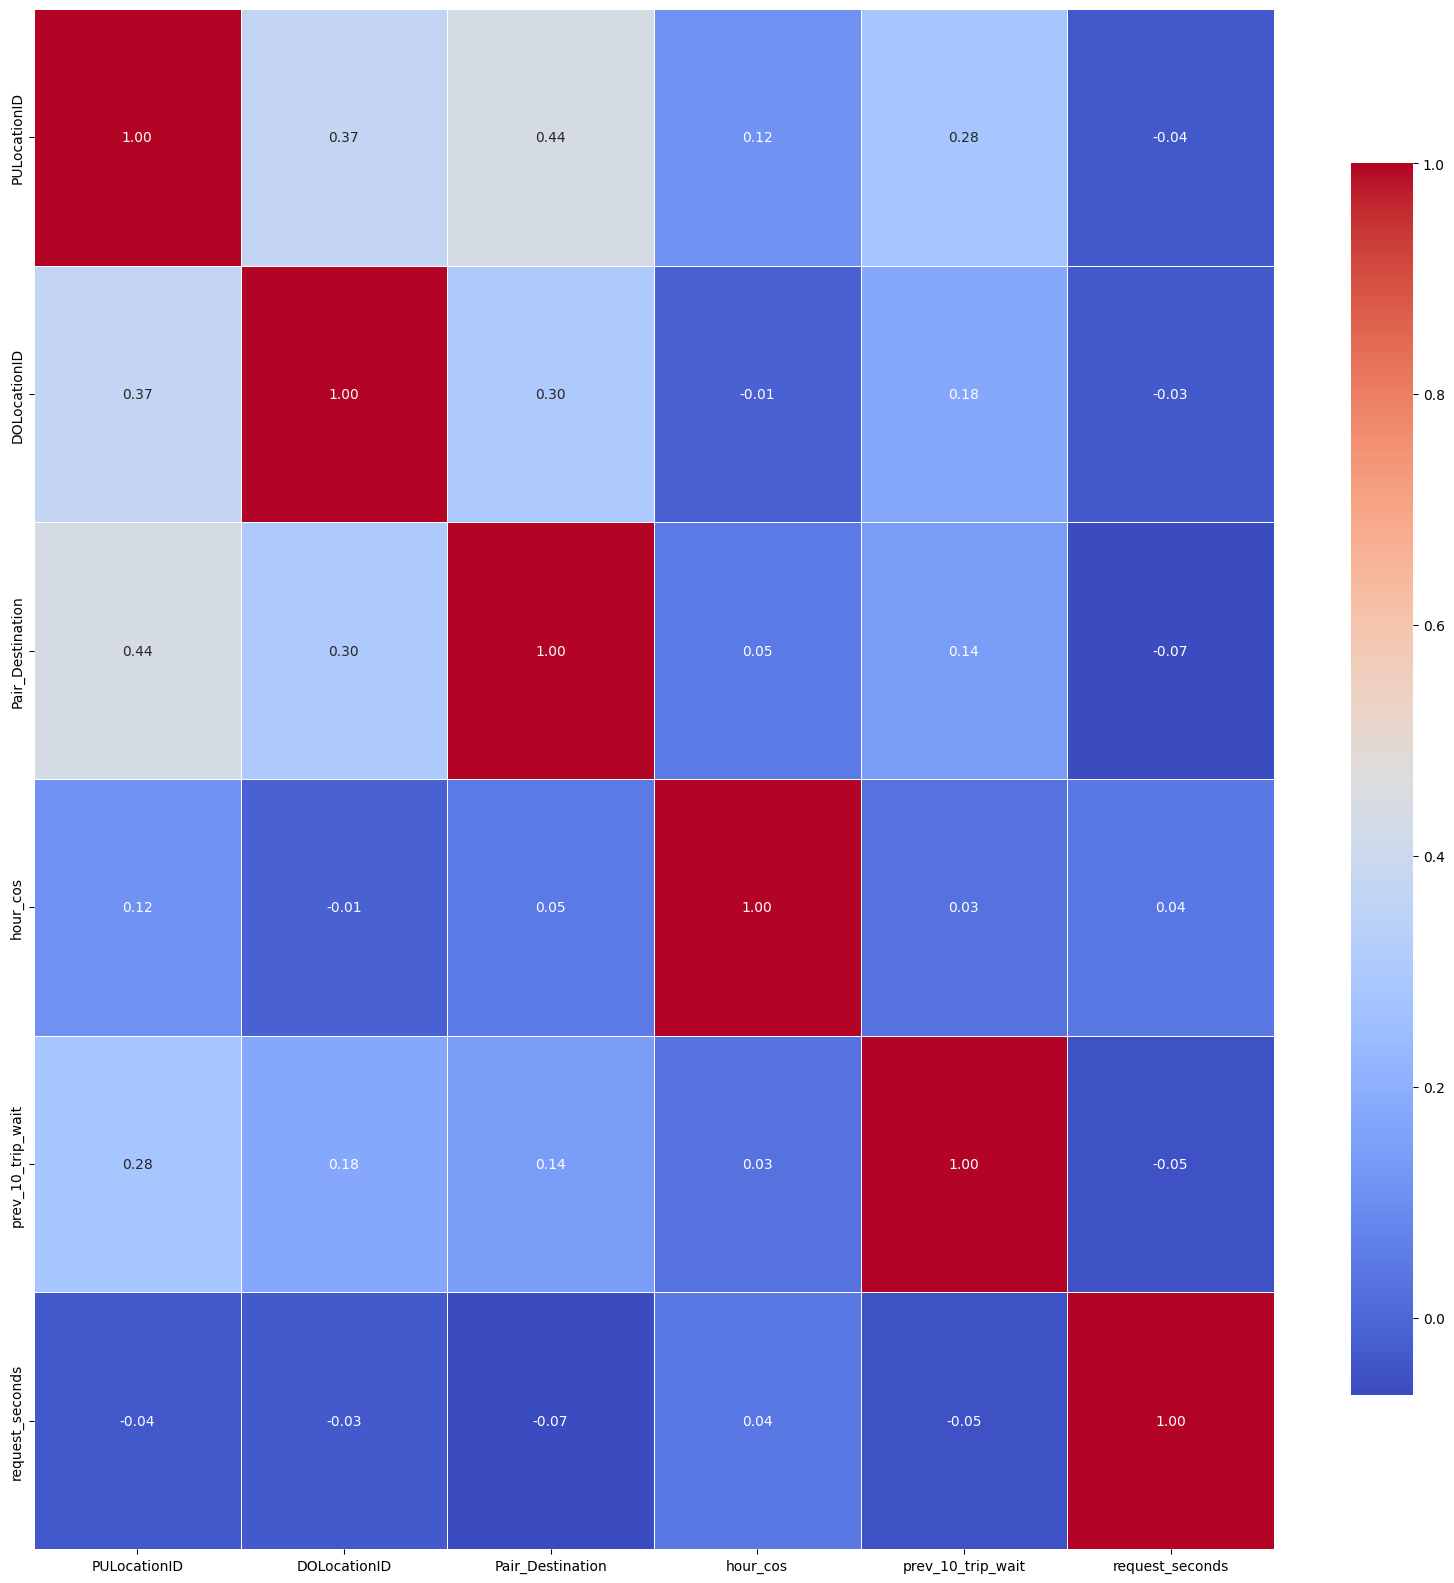

In [40]:
rfe_corr = X_train_encoded_c[selected_features].corr(method='pearson')
plt.figure(figsize=(20,20))
sns.heatmap(
    rfe_corr,
    annot = True,
    fmt = '.2f',
    cmap='coolwarm', 
    linewidths=0.5,          
    cbar_kws={"shrink": .8}  
    
)
plt.show()

In [ ]:
scores = cross_val_score(new_rfc, X_train_scaled, y_train2, cv=5, scoring='f1_macro')
scores

In [42]:
param_grid = {
    "n_estimators": [100, 200, 300],           # Number of trees
    "max_depth": [None, 10, 20, 30],            # Limits how 'deep' the model memorizes
    "min_samples_leaf": [1,2,4],         # Minimum samples to be a leaf
    "max_features": ["sqrt", "log2"],     # How many features to look at per split
    "class_weight": ["balanced", 'balanced_subsample'] # Adjusting for that High/Low imbalance
}
# 3. Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    scoring='f1_macro', 
    cv=3,              
    verbose=2,
    n_jobs=-1,
)


#Note: GridSearchCV is better than RandomSearch as GridSearch checks all combination possible, RandomSearch is better in time complexity wise. 


In [43]:
grid_search.fit(X_train_scaled, y_train2)

#Fit the best parameters into the RFC model
rfc_params = grid_search.best_params_
best_rfc = RandomForestClassifier(**rfc_params)
best_rfc.fit(X_train_scaled, y_train2)
y_pred = best_rfc.predict(X_test_scaled)


scores = cross_val_score(best_rfc, X_train_scaled, y_train2, cv=5, scoring='f1_macro')
result_df.loc[3] = {'f1_score (Random Fold)': f1_score(y_test2, y_pred, average='macro'), 'model': 'RFECV + GridSearchCV + RFC'}
evaluation(y_test2, y_pred)


print("\nFeature Importances:")
feature_importances = pd.Series(best_rfc.feature_importances_, index=X_train_encoded_c[selected_features].columns).sort_values(ascending=False)
print(feature_importances)
evaluation(y_test2, y_pred)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=  11.7s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=  12.5s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=  13.5s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=  27.3s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=  27.5s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time=  29.1s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=  15.6s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, mi

In [45]:
import xgboost as xgb
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded_c)
X_test_scaled = scaler.transform(X_test_encoded_c)
xgb_model = xgb.XGBClassifier(random_state = 42)
xgb_model.fit(X_train_scaled, y_train2)
y_pred = xgb_model.predict(X_test_scaled)
prediction_score = xgb_model.predict_proba(X_test_scaled)[:,1]
y_pred = (prediction_score >= 0.5).astype(int)
result_df.loc[3] = {'f1_score (Random Fold)': f1_score(y_test2, y_pred, average='micro'), 'model': 'XGB Model' }
result_df

print("\nFeature Importances:")
feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train_encoded_c.columns).sort_values(ascending=False)
print(feature_importances)
evaluation(y_test2, y_pred)


Feature Importances:
is_rush_hour                                 0.146122
day_cos                                      0.128331
do_density_last_hour                         0.127041
congestion_surcharge                         0.051803
airport_fee                                  0.049235
hour_cos                                     0.044955
request_seconds                              0.044082
pu_density_last_hour do_density_last_hour    0.042501
PULocationID                                 0.037923
Borough_Manhattan                            0.033432
Borough_Brooklyn                             0.032947
DOLocationID                                 0.032230
request_day                                  0.032201
Borough_Queens                               0.028701
Pair_Destination                             0.022391
hour_sin                                     0.019307
Borough_Staten Island                        0.018919
day_sin                                      0.018410
prev_1

In [46]:
#RFE Model 
xgb_model = xgb.XGBClassifier(objective = 'binary:logistic', eval_metric = 'logloss', random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded_c[selected_features])
X_test_scaled = scaler.transform(X_test_encoded_c[selected_features])

xgb_model.fit(X_train_scaled, y_train2)
y_pred = xgb_model.predict(X_test_scaled)
result_df.loc[4] = {'f1_score (Random Fold)': f1_score(y_test2, y_pred, average='micro'), 'model': 'RFE XGB Model' }
print(result_df)


print("\nFeature Importances:") 
feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train_encoded_c[selected_features].columns).sort_values(ascending=False)
print(feature_importances)

evaluation(y_test2, y_pred)


  f1_score (Random Fold)               model Feature Importance
0               0.622295  LogisticRegression                NaN
1               0.634721                 RFC                NaN
2               0.635027           RFC + RFE                NaN
3               0.577577           XGB Model                NaN
4               0.555902       RFE XGB Model                NaN

Feature Importances:
hour_cos             0.376618
PULocationID         0.173891
DOLocationID         0.152551
request_seconds      0.130712
Pair_Destination     0.116640
prev_10_trip_wait    0.049588
dtype: float32
classification_report
              precision    recall  f1-score   support

           0       0.77      0.52      0.62      4459
           1       0.37      0.64      0.47      1954

    accuracy                           0.56      6413
   macro avg       0.57      0.58      0.54      6413
weighted avg       0.65      0.56      0.57      6413

Confusion Matrix
[[2313 2146]
 [ 702 1252]]


In [ ]:
xgb_corr = X_train_encoded_c[selected_features].corr()
plt.figure(figsize=(20,20))
sns.heatmap(
    xgb_corr,
    annot = True,
    fmt = '.2f',
    cmap='coolwarm', 
    linewidths=0.5,          
    cbar_kws={"shrink": .8}  
    
)   
plt.show()

In [721]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgb_model, X_train_scaled, y_train2, cv=5, scoring='f1_micro')
result_df.loc[5] = {'f1_score (Random Fold)': scores.sum()/5, 'model': 'XGB + RFE'}
scores

array([0.76944065, 0.75521341, 0.76335283, 0.75321637, 0.75575049])

In [722]:
vif_df = X_train_encoded[final_features].apply(pd.to_numeric, errors='coerce')
vif_df = vif_df.astype(float)
intercept = add_constant(vif_df)
vif_data = pd.DataFrame()
vif_data['Feature'] = intercept.columns
vif_data['VIF_Score'] = [variance_inflation_factor(intercept.values, i) for i in range(intercept.shape[1])]
print(vif_data.reset_index().sort_values(by='VIF_Score', ascending=False))

   index                  Feature  VIF_Score
0      0                    const  28.179857
2      2               trip_miles   2.419023
4      4  driver_pay_yj_winsorize   2.355922
3      3         Pair_Destination   1.521109
1      1             PULocationID   1.501916
5      5         Borough_Brooklyn   1.007528
6      6          request_seconds   1.005779


In [ ]:
#RANDOM GRID SEARCH (GridSearchCV is better)
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "max_depth": [3, 5, 7, 9],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3, 0.5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 300, 500],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 1.5, 2]
}

search = RandomizedSearchCV(
    rfc,
    param_distributions=param_grid,
    n_iter=100,
    scoring='f1_micro',
    cv=5,
    verbose=1,      
    n_jobs=-1
)
search.fit(X_train_scaled, y_train2)

In [734]:
print(search.best_params_)
print(search.best_score_)

#{'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}
# 0.784848598909774

{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}
0.7822391662041264


In [733]:
#TUNED XGB
from xgboost import XGBClassifier
xgb = XGBClassifier(**search.best_params_, scoring='f1_micro', objective = 'binary:logistic', eval_metric = 'logloss', random_state = 42)
xgb.fit(
    X_train_scaled, y_train2,
    verbose = False
)
y_probs = xgb.predict(X_test_scaled)
result_df.loc[4] = {'f1_score (Random Fold)': f1_score(y_test2, y_pred, average='micro'), 'model': 'Random Hyper Param Tuning XGBModel'}
result_df

,f1_score (Random Fold),model,Feature Importance
0,1.553095,LogisticRegression,NaN
1,0.765242,RFC,NaN
2,0.596289,XGB Model,NaN
3,0.600187,RFE XGB Model,NaN
5,0.759395,XGB + RFE,NaN
4,0.600187,Random Hyper Param Tuning XGBModel,NaN


In [742]:
X_train_scaled = scaler.fit_transform(X_train_encoded_c[selected_features])
X_test_scaled = scaler.transform(X_test_encoded_c[selected_features])
xgb = XGBClassifier(**search.best_params_, scoring='f1_micro', objective = 'binary:logistic', eval_metric = 'logloss', random_state = 42)
xgb.fit(
    X_train_scaled, y_train2,
    verbose = False,
)

y_pred = xgb.predict(X_test_scaled)
result_df.loc[5] = {'f1_score (Random Fold)': f1_score(y_test2, y_pred, average='micro'), 'model': 'Random Hyper Param Tuning + RFE,  XGBModel'}
result_df

,f1_score (Random Fold),model,Feature Importance
0,1.553095,LogisticRegression,NaN
1,0.765242,RFC,NaN
2,0.596289,XGB Model,NaN
3,0.600187,RFE XGB Model,NaN
5,0.597692,"Random Hyper Param Tuning + RFE, XGBModel",NaN
4,0.600187,Random Hyper Param Tuning XGBModel,NaN


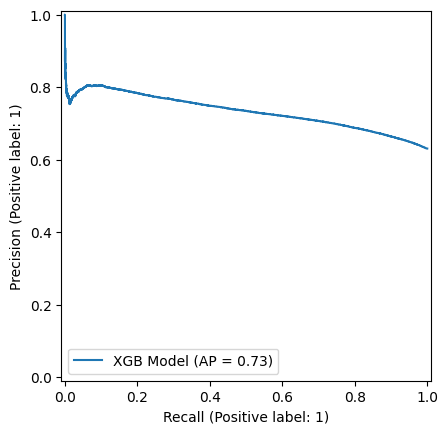

In [293]:
PrecisionRecallDisplay.from_predictions(y_test2, y_probs, name="XGB Model")
plt.show()



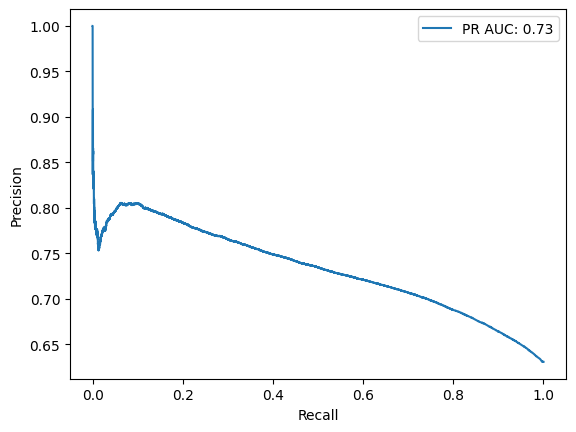

In [294]:
from sklearn.metrics import auc
precision, recall, thresholds = precision_recall_curve(y_test2, y_probs)

# Optional: Calculate Area Under Curve (AUC) for PR
pr_auc = auc(recall, precision)

# Manual plot
plt.plot(recall, precision, label=f'PR AUC: {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()        
plt.show()


In [287]:
print("\nFeature Importances:") 
feature_importances = pd.Series(xgb.feature_importances_, index=X_train_encoded_c[final_features].columns).sort_values(ascending=False)
print(feature_importances)


Feature Importances:
Ride_Type_Uber WAV Regular                                 0.409243
Pair_Destination                                           0.201170
Ride_Type_Uber_Regular Borough_Manhattan                   0.131189
Ride_Type_Uber WAV Regular request_hour                    0.105634
Ride_Type_Uber_Regular request_hour                        0.081447
Ride_Type_Uber_Regular request_day                         0.040974
base_passenger_fare_yj_winsorize Ride_Type_Uber_Regular    0.030342
dtype: float32


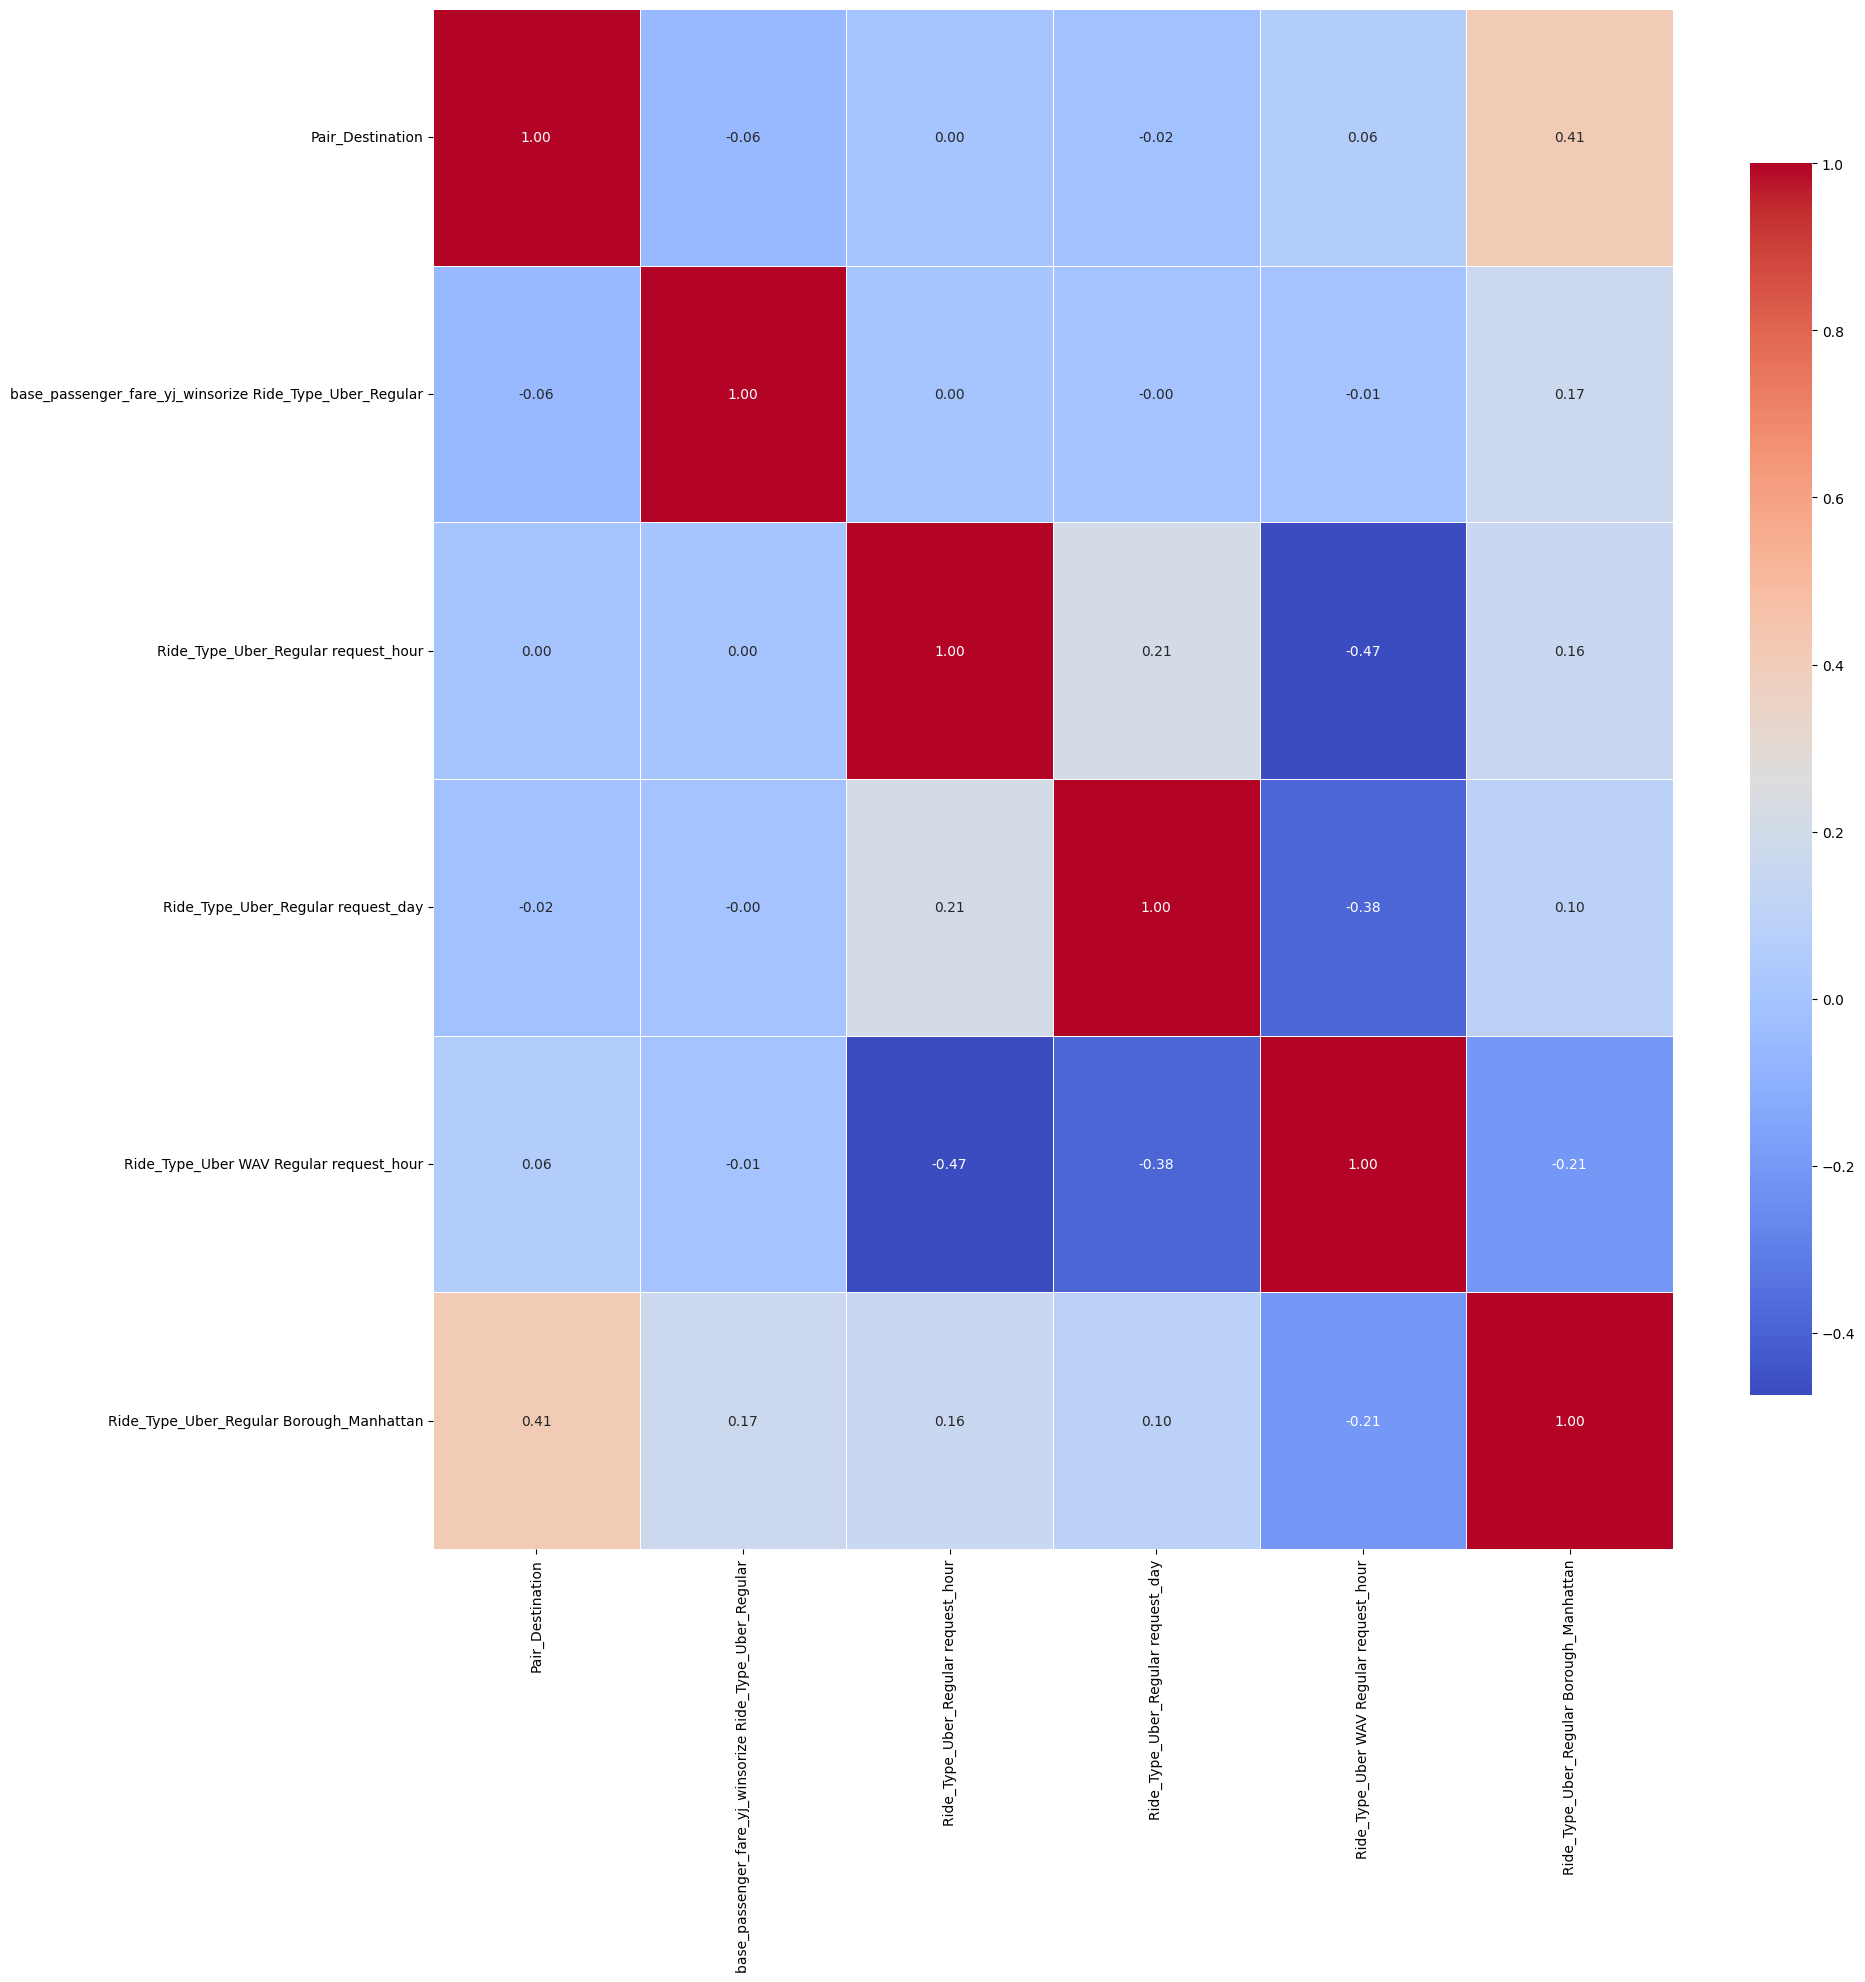

In [295]:
xgb_corr = X_train_encoded_c[final_features].corr()
plt.figure(figsize=(20,20))
sns.heatmap(
    xgb_corr,
    annot = True,
    fmt = '.2f',
    cmap='coolwarm', 
    linewidths=0.5,          
    cbar_kws={"shrink": .8}  
    
)
plt.show()

In [296]:
#Confusion Matrix and Classification Report
conf_matrix = confusion_matrix(y_test2, y_pred)
class_report = classification_report(y_test2, y_pred)
print(conf_matrix)
print('*******************')
print(class_report)


[[32842 30260]
 [33988 73790]]
*******************
              precision    recall  f1-score   support

           0       0.49      0.52      0.51     63102
           1       0.71      0.68      0.70    107778

    accuracy                           0.62    170880
   macro avg       0.60      0.60      0.60    170880
weighted avg       0.63      0.62      0.63    170880



### OTHER CODE USED TO TRY AND ANSWER QUESTION

In [ ]:
#Sequential Feature Selection via Backward Selection
from sklearn.feature_selection import SequentialFeatureSelector

selector = SequentialFeatureSelector(
    log_model,
    n_features_to_select = 46,
    direction = 'backward',
    scoring = 'f1',
    cv = 5
)


X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_encoded.columns
)


selector.fit(X_train_scaled, y_train2)
selected_feature_mask = selector.get_support()
selected_feature_name = X_train_scaled.columns[selected_feature_mask]
print(f"Original features: {list(feature_names)}")
print(f"Selected features: {list(selected_feature_name)}") 

# ## 6. Use the transformed data
# # You can use transform() to reduce your dataset to only the selected features
# X_train_selected = selector.transform(X_train)
# X_test_selected = selector.transform(X_test)


In [ ]:
#Decision Tree Classification 3 Depth based on Gini Impurity, Balanced use Inverse of Freq as weight

clf_tree = DecisionTreeClassifier(max_depth=6, min_samples_split = 2, 
        class_weight = 'balanced', criterion='gini', 
        random_state =42)
clf_tree.fit(X_train_scaled, y_train2)


plt.figure(figsize=(40, 50), dpi=500)
fig = plot_tree(clf_tree,
feature_names=X_train_scaled.columns,
          class_names=['Low', 'Medium', 'High'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True, precision=2)

# plt.show()
fig.savefig('full_decision_tree.pdf', format='pdf')

In [122]:
from sklearn.linear_model import LassoLarsIC   
from sklearn.pipeline import make_pipeline

bic = make_pipeline(LassoLarsIC(criterion="bic"))
l_scale = LabelEncoder()
y_train2 = l_scale.fit_transform(y_train2)
bic.fit(X_train_scaled, y_train2)

results2 = pd.DataFrame({
    'alphas': bic[-1].alphas_,
    'BIC Criterion': bic[-1].criterion_
    'coefficents': bic[-1].coef_
})


In [ ]:
import itertools
comb , aic , bic = [] , []  , []
feature_names = list(X_train_encodedcolumns[:-1])

all_feature_combinations = []
for r in range(1, len(feature_names) + 1):
    all_feature_combinations.extend(itertools.combinations(feature_names, r))

for subset in all_feature_combinations:

    x = X_train_encoded[list(subset)]
    y = y_train2.iloc[:,-1]
    
   

    result = sm.Logit(y, sm.add_constant(x)).fit()
    
    comb.append(subset)
    aic.append(result.aic)
    bic.append(result.bic)


log_aic = pd.DataFrame({'Parameter Combination': comb, 'AIC': aic, 'BIC': bic}).sort_values(by = 'AIC')
Optimization terminated successfully.
         Current funct

In [124]:
#BIC RESULTS (Alpha = Regularization Strength)
results_bic.head(40)


,alphas,BIC Criterion
0,0.130833,4.546444e+06
1,0.038001,4.484256e+06
2,0.014593,4.474398e+06
3,0.011298,4.473502e+06
4,0.010804,4.473358e+06
5,0.010119,4.473124e+06
6,0.007568,4.472156e+06
7,0.007568,4.472171e+06
8,0.007384,4.472149e+06
9,0.006363,4.471850e+06


**************************************************************************************************